# Intrusion Detection System (ML & Deep Learning)
## SDN-IoT Network Traffic — ASEADOS

**Dataset:** ASEADOS_SDN_IoT (flow features, multi-class labels)  
**Reference papers (optional background):** Mahmud et al. (2024); Makris et al. (2025)

**Pipeline:** Data cleaning → EDA → traditional ML → deep learning → federated learning → reinforcement learning → save models → Flask UI


---
## 1. Setup & Imports

In [1]:
%pip install numpy pandas matplotlib seaborn scikit-learn imbalanced-learn tensorflow xgboost lightgbm plotly joblib flask


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\mdsha\gpu_env\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotly is optional (interactive charts). If missing, the notebook will still run.
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False
    print("plotly not installed (install with: pip install plotly)")

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('xgboost not installed, skipping XGBoost model')

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print('lightgbm not installed, skipping LightGBM model')

import joblib
import json
import os
import copy
import time
from collections import defaultdict

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')
print('Setup complete!')

TensorFlow version: 2.21.0
GPU available: False
Setup complete!


---
## 2. Data Loading & Initial Inspection

In [3]:
DATA_PATH = 'ASEADOS_SDN_IoT.csv'

df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
print(f'Total samples: {df.shape[0]:,}')
print(f'Total features: {df.shape[1]}')
print(f'\nColumn dtypes:\n{df.dtypes.value_counts()}')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: (457044, 84)
Total samples: 457,044
Total features: 84

Column dtypes:
float64    45
int64      34
str         5
Name: count, dtype: int64

First 5 rows:


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,8.128.192.168-85.245.192.168-0-0-0,85.245.192.168,0,8.128.192.168,0,0,12/03/2025 03:07:04 PM,3241760,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.616949,3241760.0,0.0,3241760.0,3241760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.308474,0.308474,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,1,0,-1,-1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Bot
1,8.128.192.168-31.125.192.168-0-0-0,31.125.192.168,0,8.128.192.168,0,0,12/03/2025 03:07:08 PM,17649667,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.113317,17649667.0,0.0,17649667.0,17649667.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.056658,0.056658,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,1,0,-1,-1,0,0,0.0,0.0,0.0,0.0,17649667.0,0.0,17649667.0,17649667.0,Bot
2,8.128.192.168-82.28.192.168-0-0-0,82.28.192.168,0,8.128.192.168,0,0,12/03/2025 03:07:07 PM,24923670,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.080245,24923670.0,0.0,24923670.0,24923670.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.040123,0.040123,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,1,0,-1,-1,0,0,0.0,0.0,0.0,0.0,24923670.0,0.0,24923670.0,24923670.0,Bot
3,8.128.192.168-76.22.192.168-0-0-0,76.22.192.168,0,8.128.192.168,0,0,12/03/2025 03:07:27 PM,5399930,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.370375,5399930.0,0.0,5399930.0,5399930.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.185188,0.185188,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,1,0,-1,-1,0,0,0.0,0.0,0.0,0.0,5399930.0,0.0,5399930.0,5399930.0,Bot
4,8.128.192.168-72.128.192.168-0-0-0,72.128.192.168,0,8.128.192.168,0,0,12/03/2025 03:07:27 PM,5436008,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.367917,5436008.0,0.0,5436008.0,5436008.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.183959,0.183959,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,1,0,-1,-1,0,0,0.0,0.0,0.0,0.0,5436008.0,0.0,5436008.0,5436008.0,Bot


In [4]:
print('=== Dataset Info ===')
print(f'Shape: {df.shape}')
print(f'\nNull values per column (top 20):')
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False).head(20))
print(f'\nTotal null values: {df.isnull().sum().sum()}')
print(f'\nDuplicate rows: {df.duplicated().sum()}')
print(f'\nLabel distribution:')
print(df['Label'].value_counts())
print(f'\nLabel percentages:')
print((df['Label'].value_counts(normalize=True) * 100).round(2))

=== Dataset Info ===
Shape: (457044, 84)

Null values per column (top 20):
Flow Byts/s    66
dtype: int64

Total null values: 66

Duplicate rows: 0

Label distribution:
Label
Benign    260797
Dos       127772
DDoS       51465
Bot         9090
Prob        7920
Name: count, dtype: int64

Label percentages:
Label
Benign    57.06
Dos       27.96
DDoS      11.26
Bot        1.99
Prob       1.73
Name: proportion, dtype: float64


In [4]:
print('=== Statistical Summary ===')
df.describe().T

=== Statistical Summary ===


,count,mean,std,min,25%,50%,75%,max
Src Port,457044.0,2.950951e+04,2.333366e+04,0.0,0.0,38494.0,4.957400e+04,6.099800e+04
Dst Port,457044.0,5.376827e+03,1.346059e+04,0.0,0.0,80.0,3.000000e+03,6.099800e+04
Protocol,457044.0,4.367177e+00,2.789368e+00,0.0,0.0,6.0,6.000000e+00,1.700000e+01
Flow Duration,457044.0,1.681224e+07,3.050907e+07,-475223.0,7317.0,162714.0,1.956054e+07,1.199996e+08
Tot Fwd Pkts,457044.0,1.040191e+01,1.944271e+02,0.0,1.0,2.0,7.000000e+00,3.099000e+04
...,...,...,...,...,...,...,...,...
Active Min,457044.0,2.588285e+05,1.730258e+06,0.0,0.0,0.0,0.000000e+00,1.140417e+08
Idle Mean,457044.0,1.243249e+07,2.459949e+07,0.0,0.0,0.0,1.498663e+07,1.199960e+08
Idle Std,457044.0,7.814503e+05,4.123237e+06,0.0,0.0,0.0,0.000000e+00,7.562769e+07
Idle Max,457044.0,1.323179e+07,2.534387e+07,0.0,0.0,0.0,1.632670e+07,1.199960e+08


---
## 3. Data Cleaning & Preprocessing
Following the methodology from [P1] Section 5.4

In [5]:
print('=== Step 1: Drop irrelevant identifier columns ===')
cols_to_drop = []
for col in ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp']:
    if col in df.columns:
        cols_to_drop.append(col)

print(f'Dropping columns: {cols_to_drop}')
df.drop(columns=cols_to_drop, inplace=True)
print(f'Shape after dropping identifiers: {df.shape}')

=== Step 1: Drop irrelevant identifier columns ===
Dropping columns: ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp']
Shape after dropping identifiers: (457044, 80)


In [6]:
print('=== Step 2: Handle infinite and missing values ===')
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

inf_counts = np.isinf(df[numeric_cols]).sum()
print(f'Columns with infinite values: {(inf_counts > 0).sum()}')
if inf_counts.sum() > 0:
    print(inf_counts[inf_counts > 0])

df.replace([np.inf, -np.inf], np.nan, inplace=True)

null_before = df.isnull().sum().sum()
print(f'\nNull values after replacing inf: {null_before}')

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

print(f'Null values after imputation: {df.isnull().sum().sum()}')

=== Step 2: Handle infinite and missing values ===
Columns with infinite values: 2
Flow Byts/s     4
Flow Pkts/s    70
dtype: int64

Null values after replacing inf: 140
Null values after imputation: 140


In [7]:
print('=== Step 3: Remove constant and near-zero variance features ===')
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
low_var_cols = [col for col in numeric_cols if df[col].std() < 1e-10]
print(f'Constant/near-zero variance columns: {low_var_cols}')
if low_var_cols:
    df.drop(columns=low_var_cols, inplace=True)
print(f'Shape after removing constant features: {df.shape}')

=== Step 3: Remove constant and near-zero variance features ===
Constant/near-zero variance columns: ['Fwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Init Fwd Win Byts', 'Fwd Seg Size Min']
Shape after removing constant features: (457044, 66)


In [8]:
print('=== Step 4: Remove duplicate rows ===')
dup_count = df.duplicated().sum()
print(f'Duplicates found: {dup_count}')
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f'Shape after removing duplicates: {df.shape}')

=== Step 4: Remove duplicate rows ===
Duplicates found: 2932
Shape after removing duplicates: (454112, 66)


In [9]:
print('=== Step 5: Strip whitespace from Label column ===')
df['Label'] = df['Label'].astype(str).str.strip()
print(f'Unique labels: {df["Label"].unique()}')
print(f'Label counts after cleaning:')
print(df['Label'].value_counts())

=== Step 5: Strip whitespace from Label column ===
Unique labels: <StringArray>
['Bot', 'DDoS', 'Dos', 'Prob', 'Benign']
Length: 5, dtype: str
Label counts after cleaning:
Label
Benign    259928
Dos       127391
DDoS       50270
Bot         8957
Prob        7566
Name: count, dtype: int64


In [10]:
print('=== Step 6: Encode labels ===')
label_encoder = LabelEncoder()
df['Label_Encoded'] = label_encoder.fit_transform(df['Label'])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f'Label mapping: {label_mapping}')

NUM_CLASSES = len(label_mapping)
CLASS_NAMES = label_encoder.classes_.tolist()
print(f'Number of classes: {NUM_CLASSES}')
print(f'Class names: {CLASS_NAMES}')

=== Step 6: Encode labels ===
Label mapping: {'Benign': np.int64(0), 'Bot': np.int64(1), 'DDoS': np.int64(2), 'Dos': np.int64(3), 'Prob': np.int64(4)}
Number of classes: 5
Class names: ['Benign', 'Bot', 'DDoS', 'Dos', 'Prob']


In [11]:
print('=== Step 7: Prepare feature matrix and target ===')
exclude_cols = ['Label', 'Label_Encoded']
feature_cols = [c for c in df.columns if c not in exclude_cols]

non_numeric = df[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f'Dropping non-numeric feature columns: {non_numeric}')
    feature_cols = [c for c in feature_cols if c not in non_numeric]

X = df[feature_cols].values.astype(np.float32)
y = df['Label_Encoded'].values

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Feature columns ({len(feature_cols)}): {feature_cols[:10]}...')

=== Step 7: Prepare feature matrix and target ===
Feature matrix shape: (454112, 65)
Target shape: (454112,)
Feature columns (65): ['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min']...


In [12]:
print('=== Step 8: Feature Correlation Analysis ===')
corr_matrix = pd.DataFrame(X, columns=feature_cols).corr().abs()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]
print(f'Highly correlated features (r > 0.95) to remove: {len(high_corr_cols)}')
if high_corr_cols:
    print(f'Removing: {high_corr_cols}')
    keep_cols = [c for c in feature_cols if c not in high_corr_cols]
    X = pd.DataFrame(X, columns=feature_cols)[keep_cols].values.astype(np.float32)
    feature_cols = keep_cols
    print(f'Shape after removing correlated features: {X.shape}')

=== Step 8: Feature Correlation Analysis ===
Highly correlated features (r > 0.95) to remove: 23
Removing: ['TotLen Bwd Pkts', 'Fwd Pkt Len Std', 'Bwd Pkt Len Std', 'Flow IAT Min', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd Header Len', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'PSH Flag Cnt', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts', 'Active Min', 'Idle Mean', 'Idle Max', 'Idle Min']
Shape after removing correlated features: (454112, 42)


In [13]:
print('=== Step 9: Train/Test Split (80/20 as per [P1]) ===')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nTraining label distribution:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {label_encoder.inverse_transform([u])[0]}: {c:,}')

=== Step 9: Train/Test Split (80/20 as per [P1]) ===
Training set: (363289, 42)
Test set: (90823, 42)

Training label distribution:
  Benign: 207,942
  Bot: 7,165
  DDoS: 40,216
  Dos: 101,913
  Prob: 6,053


In [14]:
print('=== Step 10: Min-Max Normalization (as per [P1] Section 5.4) ===')
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training feature range: [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]')
print(f'Test feature range: [{X_test_scaled.min():.4f}, {X_test_scaled.max():.4f}]')
print('Normalization complete!')

=== Step 10: Min-Max Normalization (as per [P1] Section 5.4) ===
Training feature range: [nan, nan]
Test feature range: [nan, nan]
Normalization complete!


In [15]:
print('=== Step 11: Handle Class Imbalance with SMOTE ===')

# SMOTE requires finite values (no NaN/inf). Sometimes NaNs can appear after scaling
# if the original data had missing/inf values that slipped through.

def make_finite(X, name='X'):
    X = np.asarray(X, dtype=np.float32)
    nan_count = int(np.isnan(X).sum())
    posinf_count = int(np.isposinf(X).sum())
    neginf_count = int(np.isneginf(X).sum())
    if nan_count or posinf_count or neginf_count:
        print(f'Found non-finite values in {name}: NaN={nan_count}, +inf={posinf_count}, -inf={neginf_count}. Fixing...')
        # Replace NaN with 0, +inf with 1, -inf with 0 (safe for MinMax-scaled features)
        X = np.nan_to_num(X, nan=0.0, posinf=1.0, neginf=0.0)
    else:
        print(f'All values finite in {name}.')
    return X

X_train_scaled = make_finite(X_train_scaled, 'X_train_scaled')
X_test_scaled = make_finite(X_test_scaled, 'X_test_scaled')

print(f'Before SMOTE: {dict(zip(*np.unique(y_train, return_counts=True)))}')

smote = SMOTE(random_state=RANDOM_STATE)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f'After SMOTE: {dict(zip(*np.unique(y_train_balanced, return_counts=True)))}')
print(f'Balanced training set shape: {X_train_balanced.shape}')

=== Step 11: Handle Class Imbalance with SMOTE ===
Found non-finite values in X_train_scaled: NaN=12, +inf=0, -inf=0. Fixing...
Found non-finite values in X_test_scaled: NaN=6, +inf=0, -inf=0. Fixing...
Before SMOTE: {np.int64(0): np.int64(207942), np.int64(1): np.int64(7165), np.int64(2): np.int64(40216), np.int64(3): np.int64(101913), np.int64(4): np.int64(6053)}
After SMOTE: {np.int64(0): np.int64(207942), np.int64(1): np.int64(207942), np.int64(2): np.int64(207942), np.int64(3): np.int64(207942), np.int64(4): np.int64(207942)}
Balanced training set shape: (1039710, 42)


In [17]:
print('=== Step 12: Prepare DL-ready datasets ===')
y_train_cat = to_categorical(y_train_balanced, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

n_features = X_train_balanced.shape[1]
X_train_cnn = X_train_balanced.reshape(-1, n_features, 1)
X_test_cnn = X_test_scaled.reshape(-1, n_features, 1)

print(f'Categorical labels - Train: {y_train_cat.shape}, Test: {y_test_cat.shape}')
print(f'CNN-shaped data - Train: {X_train_cnn.shape}, Test: {X_test_cnn.shape}')
print(f'Number of input features: {n_features}')
print('\nData preprocessing complete!')

=== Step 12: Prepare DL-ready datasets ===
Categorical labels - Train: (1039710, 5), Test: (90823, 5)
CNN-shaped data - Train: (1039710, 42, 1), Test: (90823, 42, 1)
Number of input features: 42

Data preprocessing complete!


---
## 4. Exploratory Data Analysis (EDA)

=== 4.1 Class Distribution ===


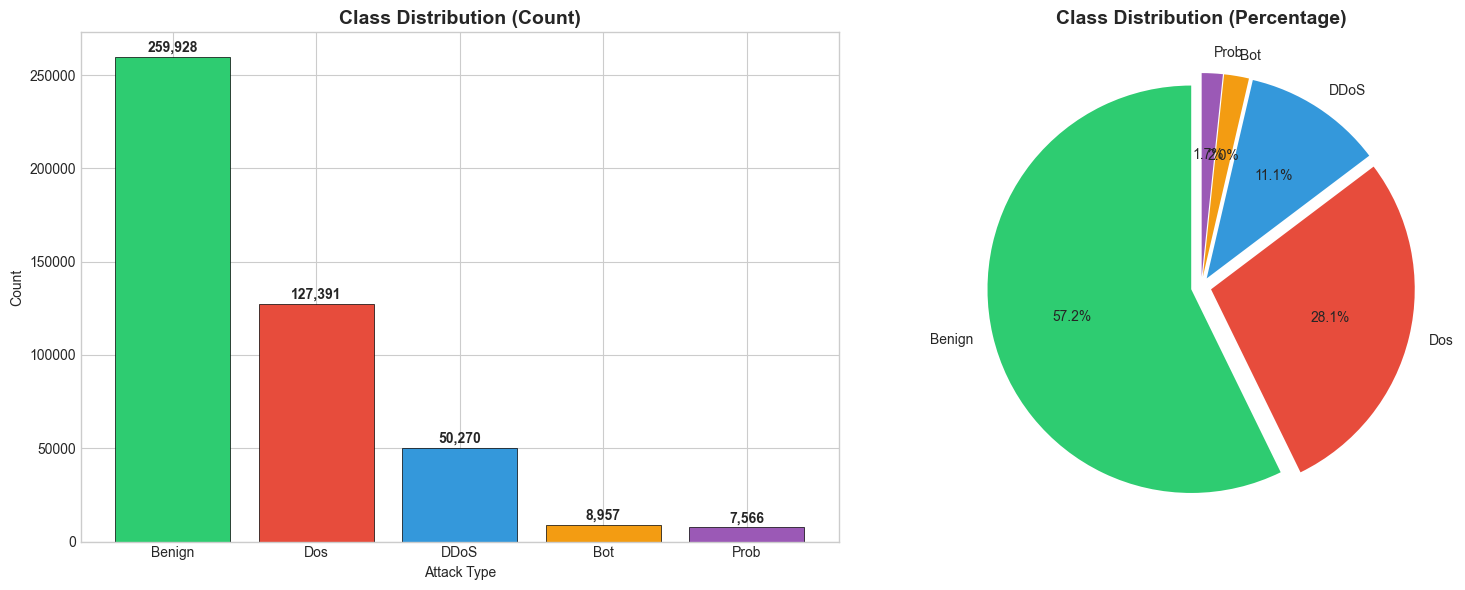

In [16]:
print('=== 4.1 Class Distribution ===')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

label_counts = df['Label'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']

bars = axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f'{val:,}', ha='center', va='bottom', fontweight='bold')

wedges, texts, autotexts = axes[1].pie(
    label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
    colors=colors, startangle=90, explode=[0.05]*len(label_counts)
)
axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

=== 4.2 Feature Distribution Analysis ===


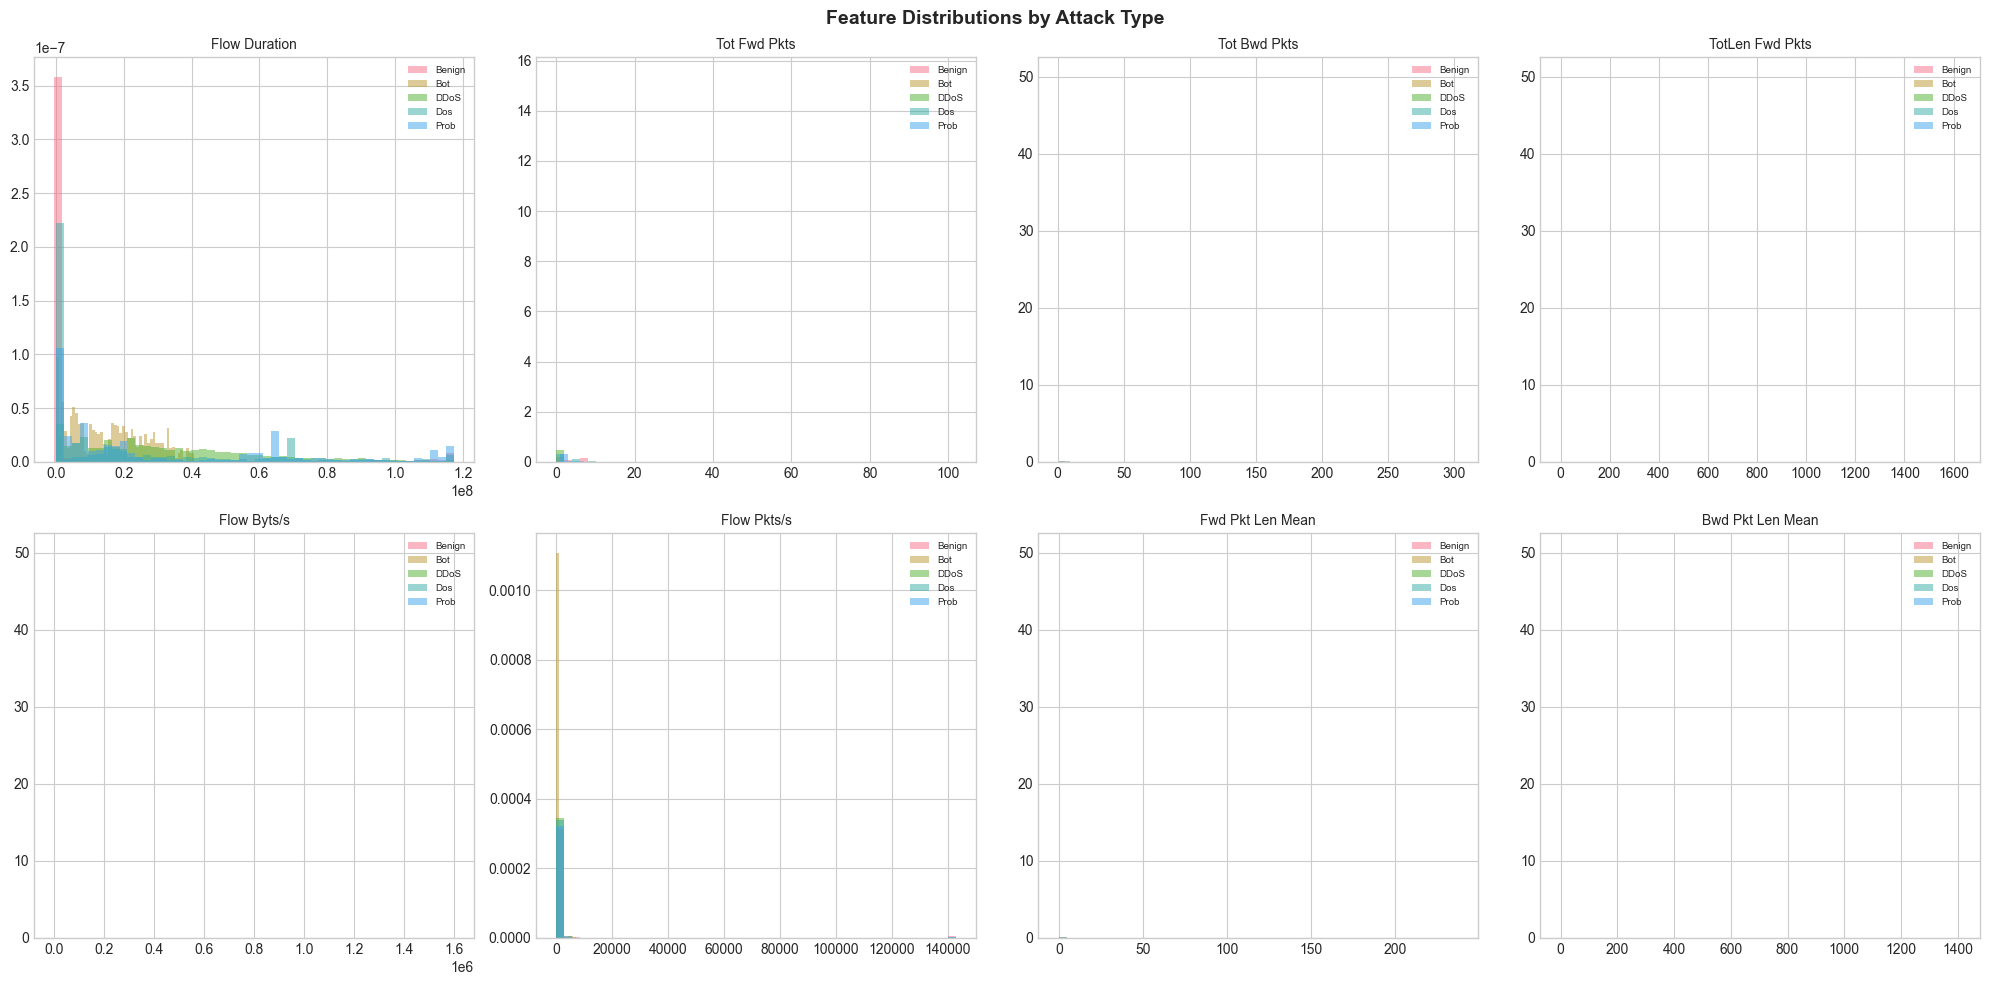

In [17]:
print('=== 4.2 Feature Distribution Analysis ===')
top_features = ['Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts',
                'Flow Byts/s', 'Flow Pkts/s', 'Fwd Pkt Len Mean', 'Bwd Pkt Len Mean']
top_features = [f for f in top_features if f in df.columns]

if top_features:
    fig, axes = plt.subplots(2, min(4, len(top_features)), figsize=(20, 10))
    axes = axes.flatten()
    for i, feat in enumerate(top_features[:8]):
        for label in CLASS_NAMES:
            subset = df[df['Label'] == label][feat].clip(upper=df[feat].quantile(0.99))
            axes[i].hist(subset, bins=50, alpha=0.5, label=label, density=True)
        axes[i].set_title(feat, fontsize=10)
        axes[i].legend(fontsize=7)
    plt.suptitle('Feature Distributions by Attack Type', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Using available numeric features for distribution plots')
    sample_features = feature_cols[:8]
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    for i, feat in enumerate(sample_features):
        df.boxplot(column=feat, by='Label', ax=axes[i])
        axes[i].set_title(feat, fontsize=9)
    plt.suptitle('Feature Distributions by Attack Type', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

=== 4.3 Correlation Heatmap ===


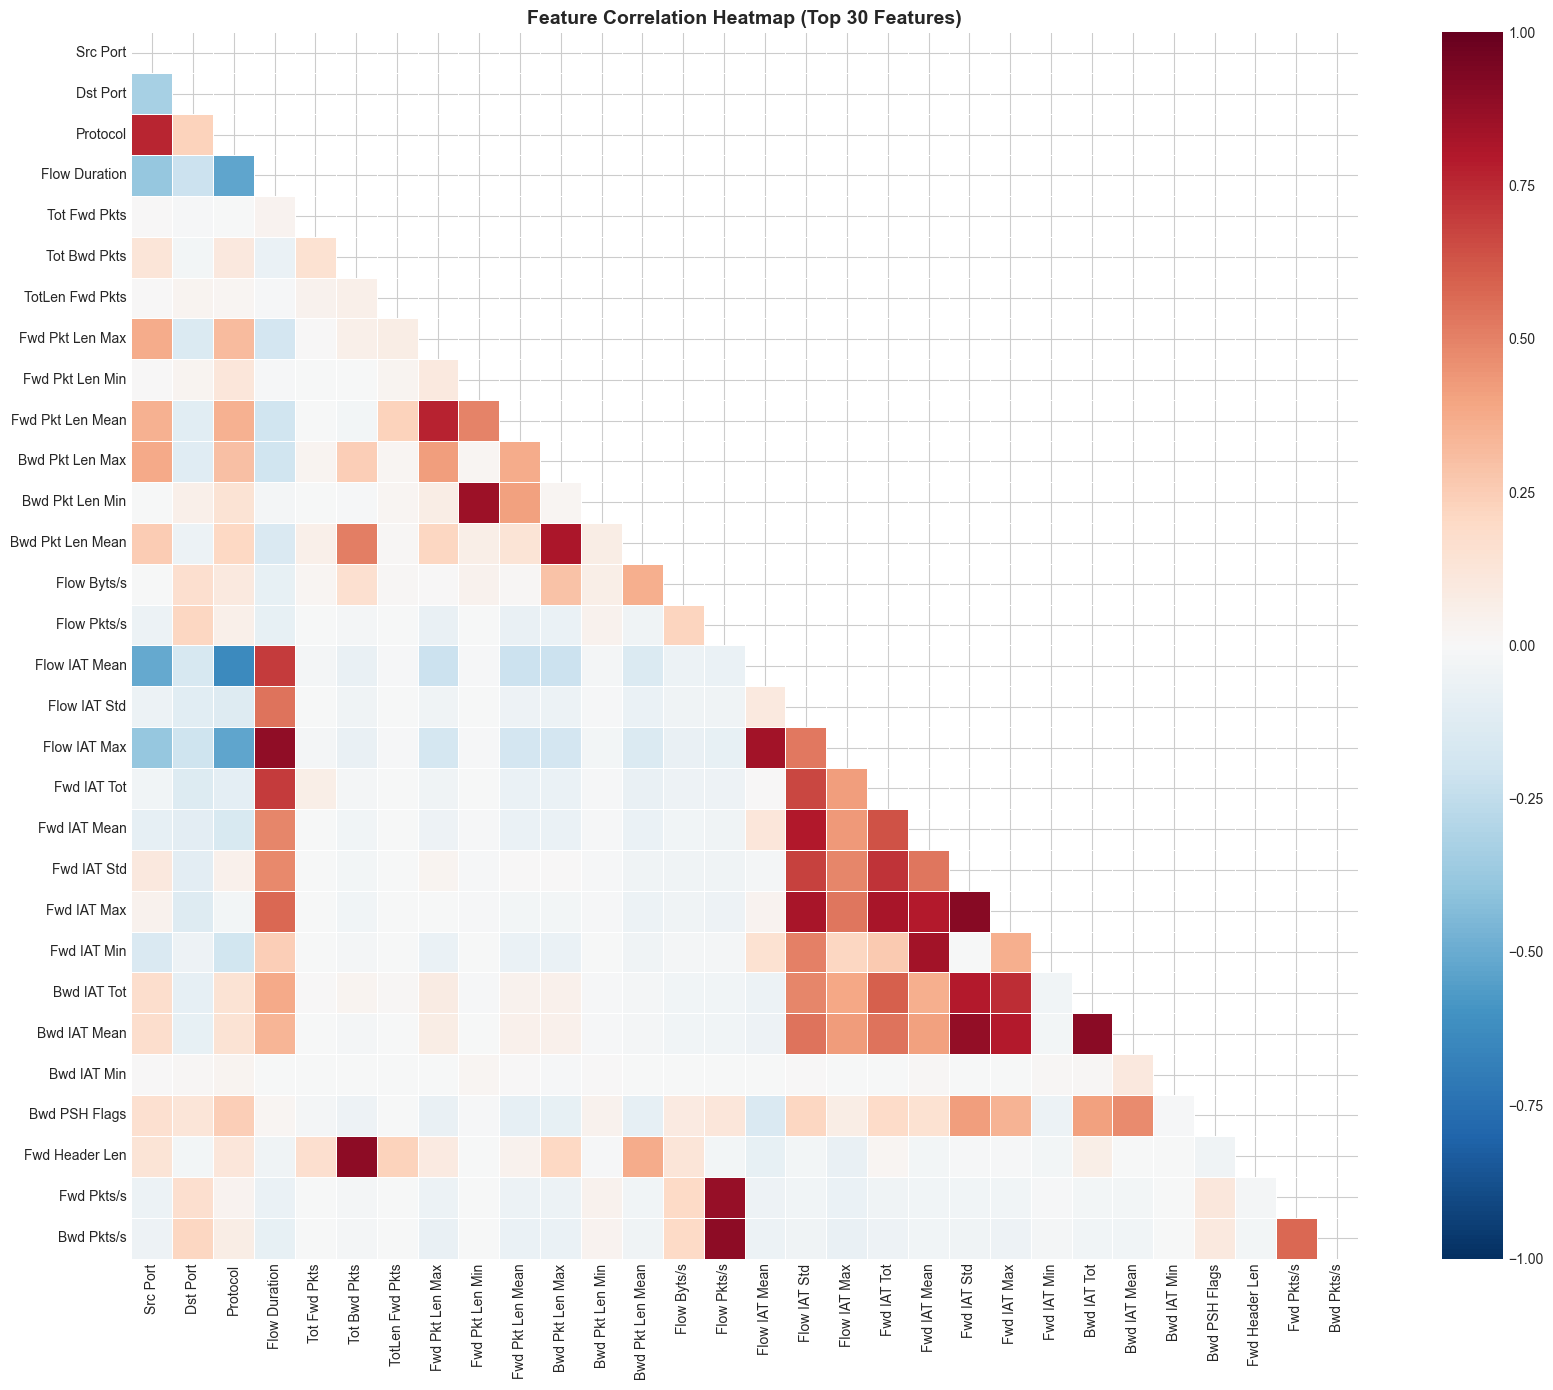

In [18]:
print('=== 4.3 Correlation Heatmap ===')
sample_features_for_corr = feature_cols[:30]
corr_df = pd.DataFrame(X_train_scaled[:, :30], columns=sample_features_for_corr)
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap (Top 30 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

=== 4.4 PCA Visualization ===


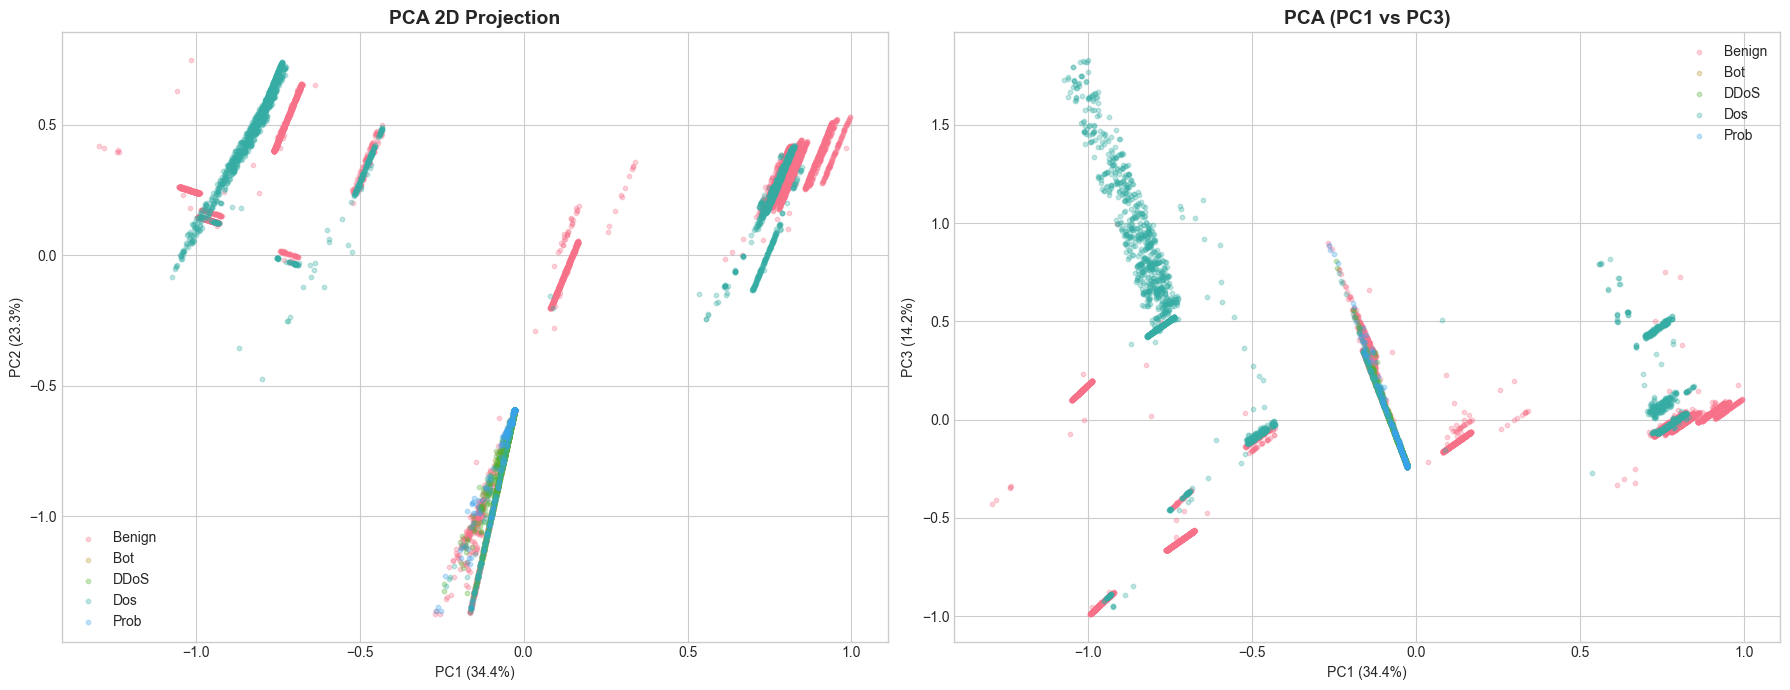

Explained variance ratio: [0.34429282 0.23304093 0.14231412]
Total variance explained by 3 PCs: 71.96%


In [19]:
print('=== 4.4 PCA Visualization ===')
from sklearn.decomposition import PCA

sample_idx = np.random.choice(len(X_train_scaled), size=min(10000, len(X_train_scaled)), replace=False)
X_sample = X_train_scaled[sample_idx]
y_sample = y_train[sample_idx]

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for cls_id, cls_name in enumerate(CLASS_NAMES):
    mask = y_sample == cls_id
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.3, s=10, label=cls_name)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA 2D Projection', fontsize=14, fontweight='bold')
axes[0].legend()

for cls_id, cls_name in enumerate(CLASS_NAMES):
    mask = y_sample == cls_id
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 2], alpha=0.3, s=10, label=cls_name)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
axes[1].set_title('PCA (PC1 vs PC3)', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total variance explained by 3 PCs: {sum(pca.explained_variance_ratio_)*100:.2f}%')

=== 4.5 Box Plots for Key Features by Attack Type ===


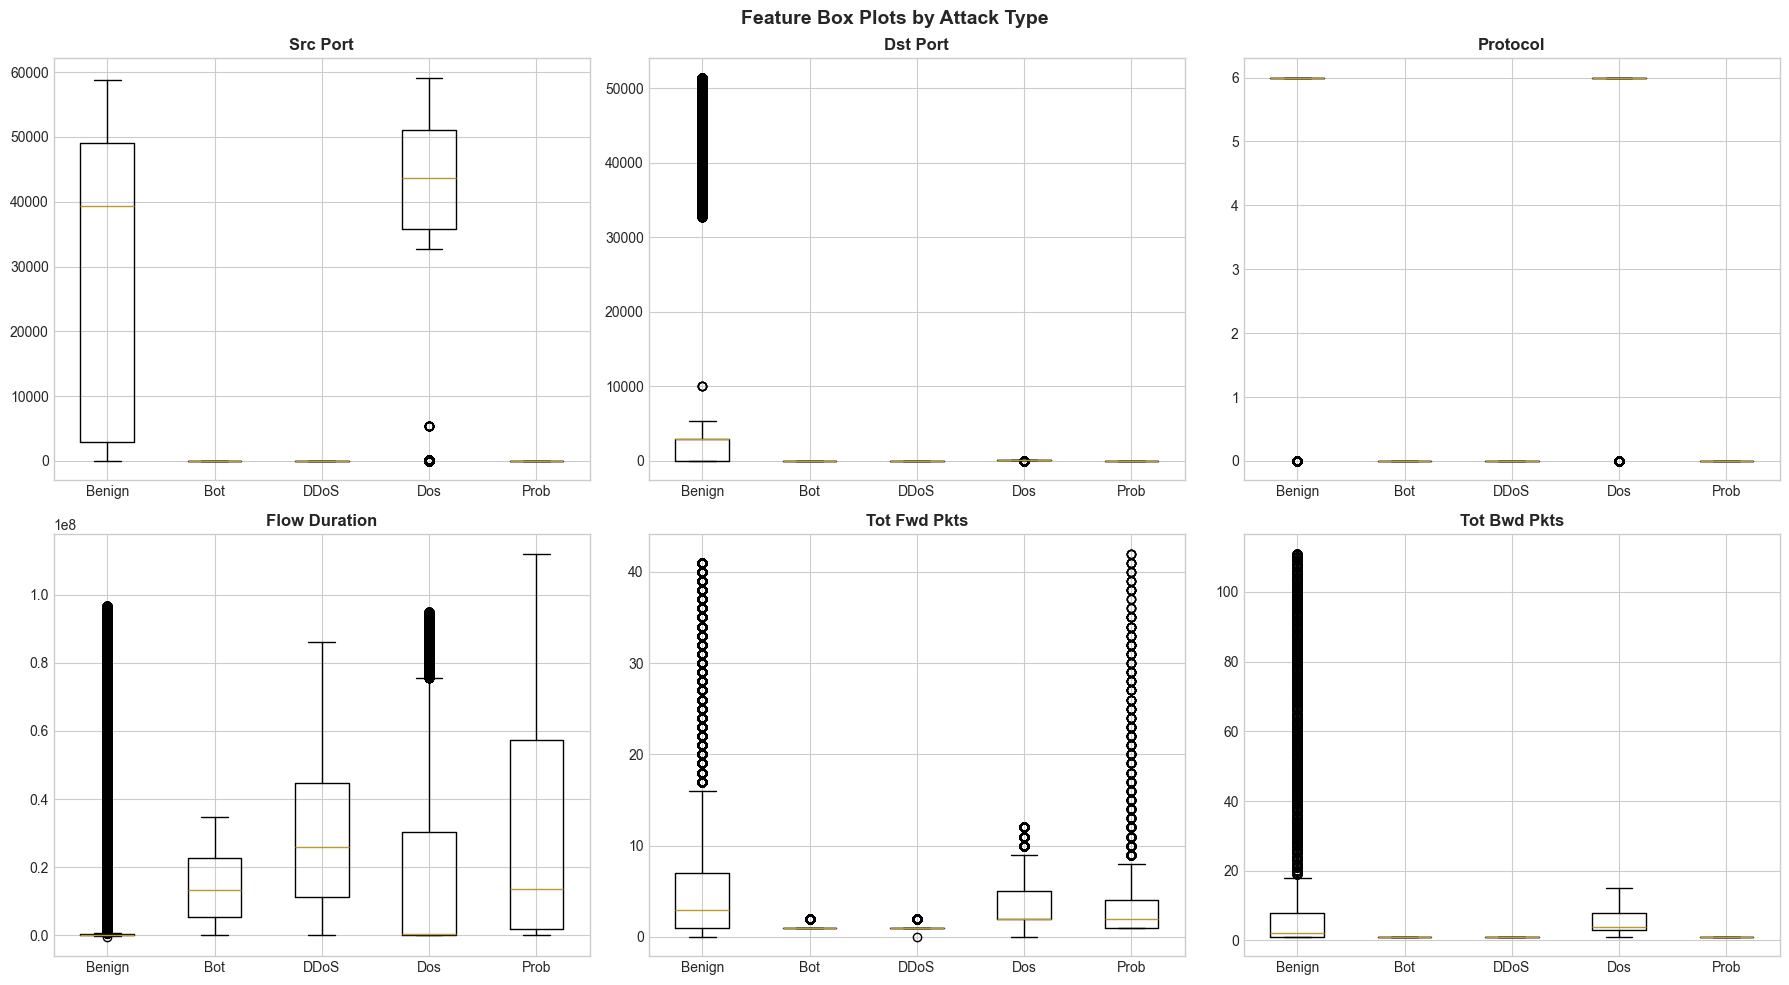

In [22]:
print('=== 4.5 Box Plots for Key Features by Attack Type ===')
plot_features = [f for f in ['Src Port', 'Dst Port', 'Protocol', 'Flow Duration',
                              'Tot Fwd Pkts', 'Tot Bwd Pkts'] if f in df.columns]
if plot_features:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for i, feat in enumerate(plot_features[:6]):
        data_for_box = []
        labels_for_box = []
        for label in CLASS_NAMES:
            vals = df[df['Label'] == label][feat]
            upper = vals.quantile(0.95)
            data_for_box.append(vals[vals <= upper])
            labels_for_box.append(label)
        axes[i].boxplot(data_for_box, labels=labels_for_box)
        axes[i].set_title(feat, fontweight='bold')
    for j in range(len(plot_features), 6):
        axes[j].axis('off')
    plt.suptitle('Feature Box Plots by Attack Type', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 5. Centralized Machine Learning Models (Baselines)

In [23]:
results = {}

def evaluate_model(name, y_true, y_pred, y_pred_proba=None):
    """Evaluate and store model performance metrics."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1,
        'y_pred': y_pred, 'y_pred_proba': y_pred_proba
    }

    print(f'\n{"="*60}')
    print(f'  {name} Results')
    print(f'{"="*60}')
    print(f'  Accuracy:  {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1 Score:  {f1:.4f}')
    print(f'{"="*60}')
    return acc

def plot_confusion_matrix(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{name} - Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'cm_{name.replace(" ", "_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Evaluation functions defined.')

Evaluation functions defined.


=== 5.1 Random Forest Classifier ===

  Random Forest Results
  Accuracy:  0.8398 (83.98%)
  Precision: 0.9090
  Recall:    0.8398
  F1 Score:  0.8664


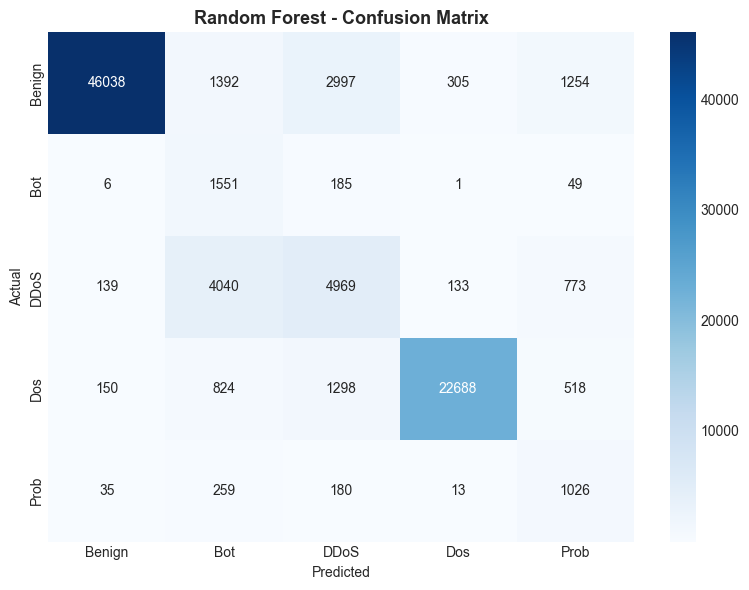


Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      0.89      0.94     51986
         Bot       0.19      0.87      0.31      1792
        DDoS       0.52      0.49      0.50     10054
         Dos       0.98      0.89      0.93     25478
        Prob       0.28      0.68      0.40      1513

    accuracy                           0.84     90823
   macro avg       0.59      0.76      0.62     90823
weighted avg       0.91      0.84      0.87     90823



In [24]:
print('=== 5.1 Random Forest Classifier ===')
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train_balanced, y_train_balanced)
rf_pred = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)
evaluate_model('Random Forest', y_test, rf_pred, rf_proba)
plot_confusion_matrix('Random Forest', y_test, rf_pred)
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=CLASS_NAMES))

=== 5.2 XGBoost Classifier ===

  XGBoost Results
  Accuracy:  0.8403 (84.03%)
  Precision: 0.9119
  Recall:    0.8403
  F1 Score:  0.8678


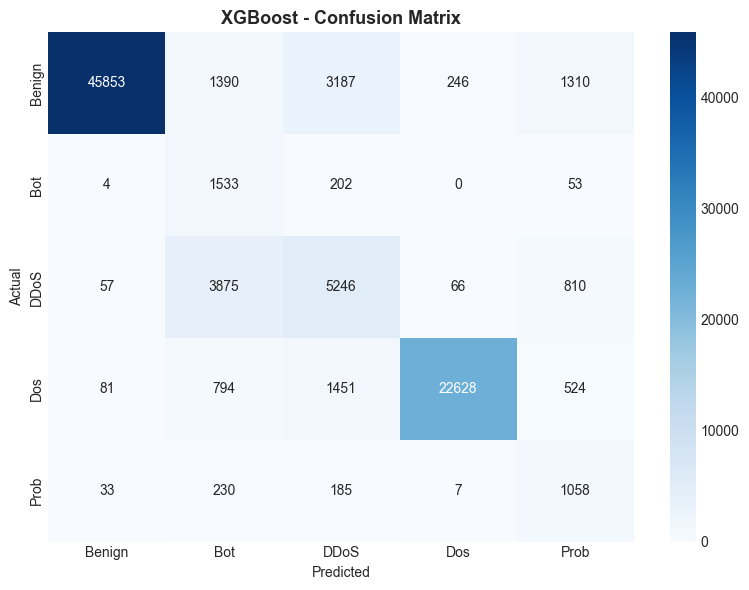


Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      0.88      0.94     51986
         Bot       0.20      0.86      0.32      1792
        DDoS       0.51      0.52      0.52     10054
         Dos       0.99      0.89      0.93     25478
        Prob       0.28      0.70      0.40      1513

    accuracy                           0.84     90823
   macro avg       0.59      0.77      0.62     90823
weighted avg       0.91      0.84      0.87     90823



In [25]:
if HAS_XGB:
    print('=== 5.2 XGBoost Classifier ===')
    xgb_model = xgb.XGBClassifier(
        n_estimators=100, max_depth=10, learning_rate=0.1,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist'
    )
    xgb_model.fit(X_train_balanced, y_train_balanced)
    xgb_pred = xgb_model.predict(X_test_scaled)
    xgb_proba = xgb_model.predict_proba(X_test_scaled)
    evaluate_model('XGBoost', y_test, xgb_pred, xgb_proba)
    plot_confusion_matrix('XGBoost', y_test, xgb_pred)
    print('\nClassification Report:')
    print(classification_report(y_test, xgb_pred, target_names=CLASS_NAMES))
else:
    print('XGBoost not available. Install with: pip install xgboost')

=== 5.3 LightGBM Classifier ===

  LightGBM Results
  Accuracy:  0.8357 (83.57%)
  Precision: 0.9126
  Recall:    0.8357
  F1 Score:  0.8652


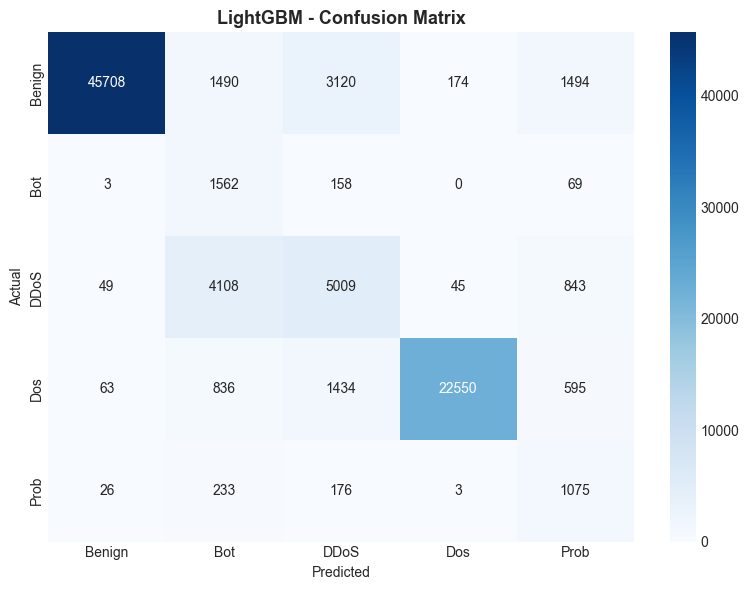


Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      0.88      0.93     51986
         Bot       0.19      0.87      0.31      1792
        DDoS       0.51      0.50      0.50     10054
         Dos       0.99      0.89      0.93     25478
        Prob       0.26      0.71      0.38      1513

    accuracy                           0.84     90823
   macro avg       0.59      0.77      0.61     90823
weighted avg       0.91      0.84      0.87     90823



In [26]:
if HAS_LGB:
    print('=== 5.3 LightGBM Classifier ===')
    lgb_model = lgb.LGBMClassifier(
        n_estimators=100, max_depth=10, learning_rate=0.1,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )
    lgb_model.fit(X_train_balanced, y_train_balanced)
    lgb_pred = lgb_model.predict(X_test_scaled)
    lgb_proba = lgb_model.predict_proba(X_test_scaled)
    evaluate_model('LightGBM', y_test, lgb_pred, lgb_proba)
    plot_confusion_matrix('LightGBM', y_test, lgb_pred)
    print('\nClassification Report:')
    print(classification_report(y_test, lgb_pred, target_names=CLASS_NAMES))
else:
    print('LightGBM not available. Install with: pip install lightgbm')

=== 5.4 Feature Importance (Random Forest) ===


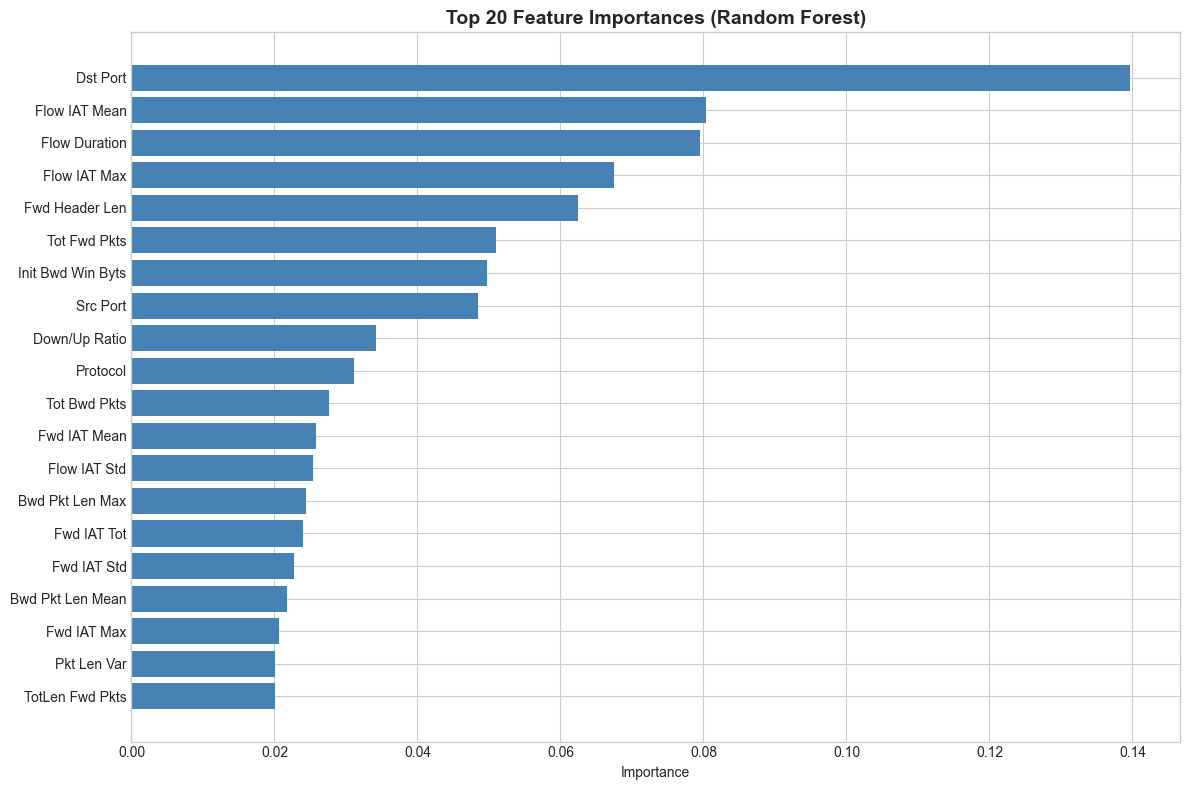

In [27]:
print('=== 5.4 Feature Importance (Random Forest) ===')
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1], color='steelblue')
ax.set_title('Top 20 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Deep Learning Models
Following architectures from [P1] Table 2 & 3

In [28]:
DL_BATCH_SIZE = 512
DL_EPOCHS = 20
DL_LEARNING_RATE = 0.01
DL_DECAY = 0.005

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

dl_histories = {}

def train_and_evaluate_dl(name, model, X_tr, y_tr, X_te, y_te):
    """Train a Keras model and evaluate it."""
    print(f'\n{"="*60}')
    print(f'  Training {name}')
    print(f'{"="*60}')
    model.summary()

    history = model.fit(
        X_tr, y_tr,
        validation_split=0.15,
        epochs=DL_EPOCHS,
        batch_size=DL_BATCH_SIZE,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    dl_histories[name] = history.history

    y_pred_proba = model.predict(X_te)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y_te, axis=1) if len(y_te.shape) > 1 else y_te

    loss = model.evaluate(X_te, y_te, verbose=0)[0]
    acc = evaluate_model(name, y_true, y_pred, y_pred_proba)
    results[name]['Loss'] = loss
    plot_confusion_matrix(name, y_true, y_pred)

    return model, history

print(f'DL Hyperparameters: batch_size={DL_BATCH_SIZE}, epochs={DL_EPOCHS}, lr={DL_LEARNING_RATE}')

DL Hyperparameters: batch_size=512, epochs=20, lr=0.01


=== 6.1 DNN Model (from [P1]: 3 hidden layers - 128, 64, 64) ===

  Training DNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           5,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,269 (75.27 KB)

 Trainable params: 18,757 (73.27 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7398 - loss: 0.6258 - val_accuracy: 0.5361 - val_loss: 1.2085 - learning_rate: 0.0100
Epoch 2/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7476 - loss: 0.6034 - val_accuracy: 0.5327 - val_loss: 1.2823 - learning_rate: 0.0100
Epoch 3/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7484 - loss: 0.5993 - val_accuracy: 0.5028 - val_loss: 1.4347 - learning_rate: 0.0100
Epoch 4/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7492 - loss: 0.5957 - val_accuracy: 0.5140 - val_loss: 1.3995 - learning_rate: 0.0100
Epoch 5/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7512 - loss: 0.5888 - val_accuracy: 0.5060 - val_loss: 1.4012 - learning_rate: 0.0050
Epoch 6/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7531 - loss: 0.5855 - val_accuracy: 0.4980 - val_loss: 1.3603 - learning_rate: 0.0050
2839/2839 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step

  DNN Results
  Accuracy:  0.80

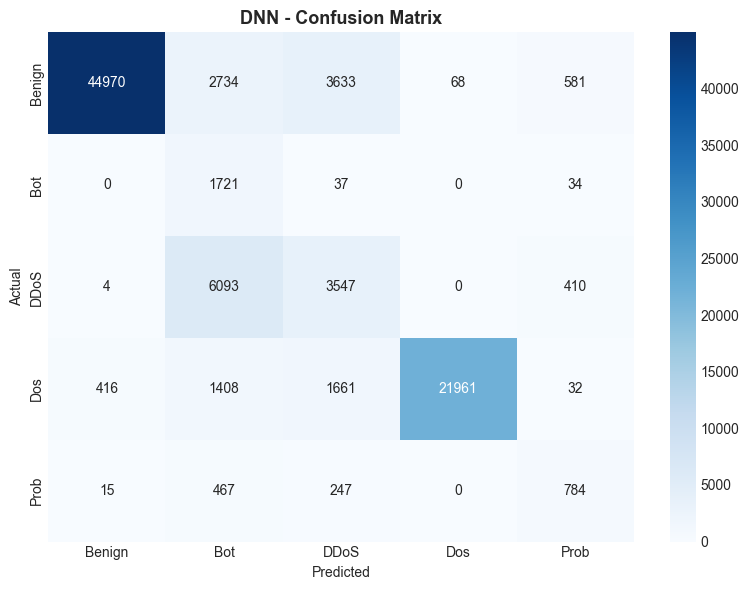

In [29]:
print('=== 6.1 DNN Model (from [P1]: 3 hidden layers - 128, 64, 64) ===')

def build_dnn(input_dim, num_classes, lr=DL_LEARNING_RATE):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

dnn_model = build_dnn(n_features, NUM_CLASSES)
dnn_model, dnn_history = train_and_evaluate_dl(
    'DNN', dnn_model, X_train_balanced, y_train_cat, X_test_scaled, y_test_cat
)

=== 6.2 LeNet/CNN Model (from [P1]: 3 conv layers - 32, 64, 256) ===

  Training LeNet


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 42, 32)              │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 42, 32)              │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 42, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 21, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 21, 64)              │          10,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 21, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 21, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 10, 256)             │          82,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 10, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 10, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 5, 256)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 258,693 (1010.52 KB)

 Trainable params: 257,989 (1007.77 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.7386 - loss: 0.6514 - val_accuracy: 0.2628 - val_loss: 2.2447 - learning_rate: 0.0100
Epoch 2/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 72s 42ms/step - accuracy: 0.7544 - loss: 0.5816 - val_accuracy: 0.2335 - val_loss: 1.8266 - learning_rate: 0.0100
Epoch 3/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 69s 40ms/step - accuracy: 0.7590 - loss: 0.5706 - val_accuracy: 0.1438 - val_loss: 1.9741 - learning_rate: 0.0100
Epoch 4/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 67s 39ms/step - accuracy: 0.7640 - loss: 0.5594 - val_accuracy: 0.2354 - val_loss: 1.5224 - learning_rate: 0.0050
Epoch 5/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 74s 43ms/step - accuracy: 0.7650 - loss: 0.5567 - val_accuracy: 0.2022 - val_loss: 2.0479 - learning_rate: 0.0050
2839/2839 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step

  LeNet Results
  Accuracy:  0.6410 (64.10%)
  Precision: 0.6392
  Recall:    0.6410
  F1 Score:  0.5511


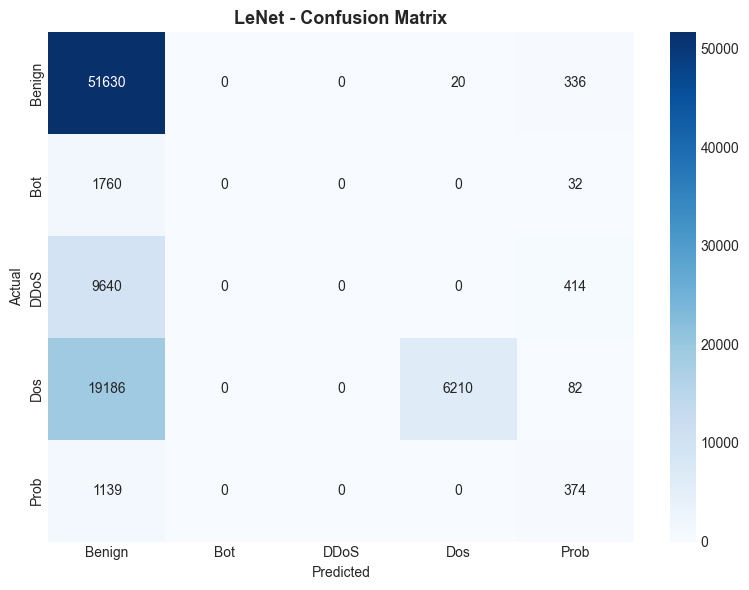

In [30]:
print('=== 6.2 LeNet/CNN Model (from [P1]: 3 conv layers - 32, 64, 256) ===')

def build_lenet(input_shape, num_classes, lr=DL_LEARNING_RATE):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(32, kernel_size=5, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(64, kernel_size=5, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.10),

        layers.Conv1D(256, kernel_size=5, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling1D(pool_size=2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.10),
        layers.Dense(num_classes, activation='softmax')
    ])
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

lenet_model = build_lenet((n_features, 1), NUM_CLASSES)
lenet_model, lenet_history = train_and_evaluate_dl(
    'LeNet', lenet_model, X_train_cnn, y_train_cat, X_test_cnn, y_test_cat
)

=== 6.3 LSTM Model (from [P1]: 4 layers - 128, 256, 512, 256) ===

  Training LSTM


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 42, 128)             │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 42, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 42, 256)             │         394,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 42, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 42, 512)             │       1,574,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 42, 512)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 256)                 │         787,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,839,941 (10.83 MB)

 Trainable params: 2,839,941 (10.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 3175s 2s/step - accuracy: 0.2392 - loss: 1.5317 - val_accuracy: 0.0000e+00 - val_loss: 2.8251 - learning_rate: 0.0100
Epoch 2/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 3109s 2s/step - accuracy: 0.2353 - loss: 1.5287 - val_accuracy: 0.0000e+00 - val_loss: 2.8291 - learning_rate: 0.0100
Epoch 3/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 3106s 2s/step - accuracy: 0.2353 - loss: 1.5287 - val_accuracy: 0.0000e+00 - val_loss: 2.8300 - learning_rate: 0.0100
Epoch 4/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 3787s 2s/step - accuracy: 0.2358 - loss: 1.5286 - val_accuracy: 0.0000e+00 - val_loss: 2.8216 - learning_rate: 0.0050
Epoch 5/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 3755s 2s/step - accuracy: 0.2358 - loss: 1.5286 - val_accuracy: 0.0000e+00 - val_loss: 2.8217 - learning_rate: 0.0050
2839/2839 ━━━━━━━━━━━━━━━━━━━━ 184s 65ms/step

  LSTM Results
  Accuracy:  0.0197 (1.97%)
  Precision: 0.0004
  Recall:    0.0197
  F1 Score:  0.0008


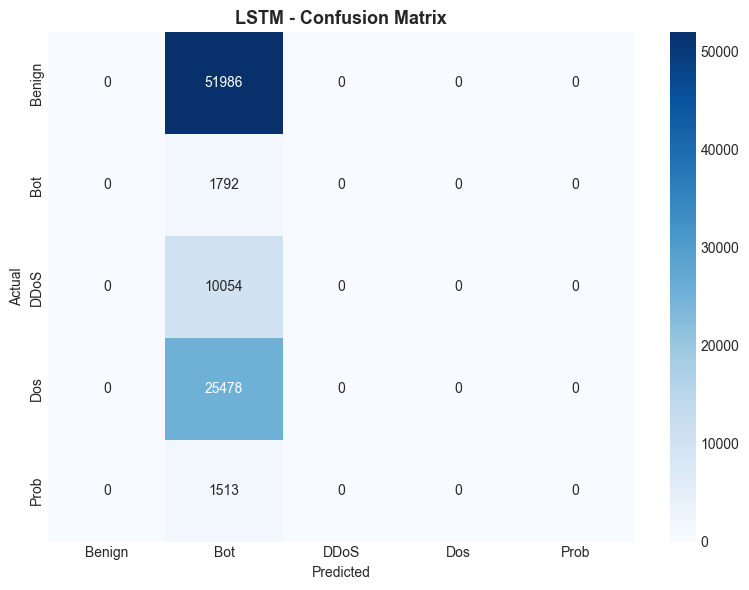

In [31]:
print('=== 6.3 LSTM Model (from [P1]: 4 layers - 128, 256, 512, 256) ===')

def build_lstm(input_shape, num_classes, lr=DL_LEARNING_RATE):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(128, return_sequences=True),
        layers.Dropout(0.3),
        layers.LSTM(256, return_sequences=True),
        layers.Dropout(0.3),
        layers.LSTM(512, return_sequences=True),
        layers.Dropout(0.3),
        layers.LSTM(256, return_sequences=False),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_lstm((n_features, 1), NUM_CLASSES)
lstm_model, lstm_history = train_and_evaluate_dl(
    'LSTM', lstm_model, X_train_cnn, y_train_cat, X_test_cnn, y_test_cat
)

=== 6.4 GRU Model (from [P1]: 2 layers - 32, 64) ===

  Training GRU


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 42, 32)              │           3,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 42, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 64)                  │          18,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,661 (104.14 KB)

 Trainable params: 26,661 (104.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 157s 89ms/step - accuracy: 0.7072 - loss: 0.6880 - val_accuracy: 0.4943 - val_loss: 1.4480 - learning_rate: 0.0100
Epoch 2/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 154s 89ms/step - accuracy: 0.7507 - loss: 0.5909 - val_accuracy: 0.5314 - val_loss: 1.2953 - learning_rate: 0.0100
Epoch 3/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 155s 90ms/step - accuracy: 0.7556 - loss: 0.5793 - val_accuracy: 0.5031 - val_loss: 1.3707 - learning_rate: 0.0100
Epoch 4/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 161s 93ms/step - accuracy: 0.7628 - loss: 0.5599 - val_accuracy: 0.5235 - val_loss: 1.2906 - learning_rate: 0.0050
Epoch 5/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 199s 115ms/step - accuracy: 0.7644 - loss: 0.5558 - val_accuracy: 0.5392 - val_loss: 1.3014 - learning_rate: 0.0050
2839/2839 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step

  GRU Results
  Accuracy:  0.8119 (81.19%)
  Precision: 0.8997
  Recall:    0.8119
  F1 Score:  0.8462


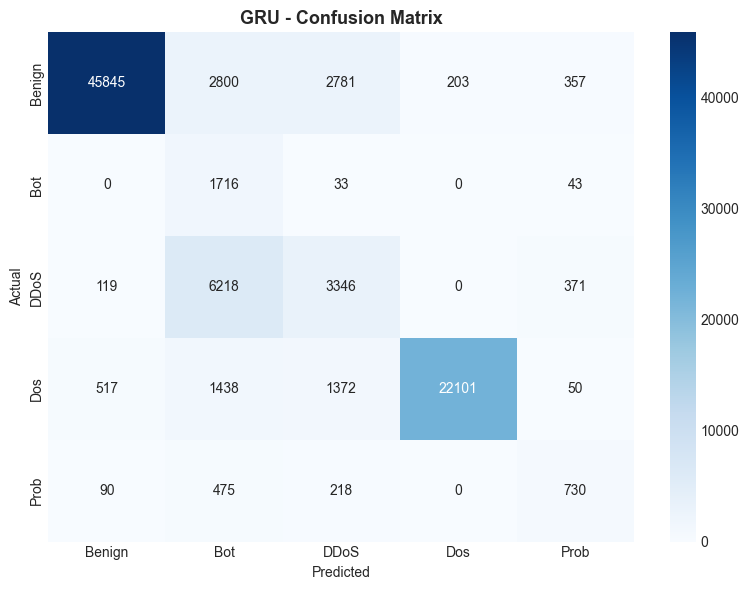

In [32]:
print('=== 6.4 GRU Model (from [P1]: 2 layers - 32, 64) ===')

def build_gru(input_shape, num_classes, lr=DL_LEARNING_RATE):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(32, return_sequences=True),
        layers.Dropout(0.1),
        layers.GRU(64, return_sequences=False),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

gru_model = build_gru((n_features, 1), NUM_CLASSES)
gru_model, gru_history = train_and_evaluate_dl(
    'GRU', gru_model, X_train_cnn, y_train_cat, X_test_cnn, y_test_cat
)

=== 6.5 FCN Model (from [P1]: 3 layers - 128, 256, 128) ===

  Training FCN


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)                    │ (None, 42, 128)             │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 42, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 42, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 42, 256)             │         164,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 42, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 42, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 42, 128)             │          98,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 42, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 42, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,373 (1.02 MB)

 Trainable params: 265,349 (1.01 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 452s 261ms/step - accuracy: 0.7432 - loss: 0.6133 - val_accuracy: 0.9976 - val_loss: 0.0198 - learning_rate: 0.0100
Epoch 2/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 443s 256ms/step - accuracy: 0.7551 - loss: 0.5803 - val_accuracy: 0.1581 - val_loss: 2.5659 - learning_rate: 0.0100
Epoch 3/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 430s 249ms/step - accuracy: 0.7586 - loss: 0.5714 - val_accuracy: 0.0118 - val_loss: 7.4109 - learning_rate: 0.0100
Epoch 4/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 438s 254ms/step - accuracy: 0.7615 - loss: 0.5641 - val_accuracy: 0.0566 - val_loss: 3.0230 - learning_rate: 0.0100
Epoch 5/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 408s 236ms/step - accuracy: 0.7653 - loss: 0.5535 - val_accuracy: 0.9695 - val_loss: 0.0852 - learning_rate: 0.0050
Epoch 6/20
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 409s 237ms/step - accuracy: 0.7666 - loss: 0.5508 - val_accuracy: 0.6884 - val_loss: 0.6876 - learning_rate: 0.0050
2839/2839 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step

  FCN R

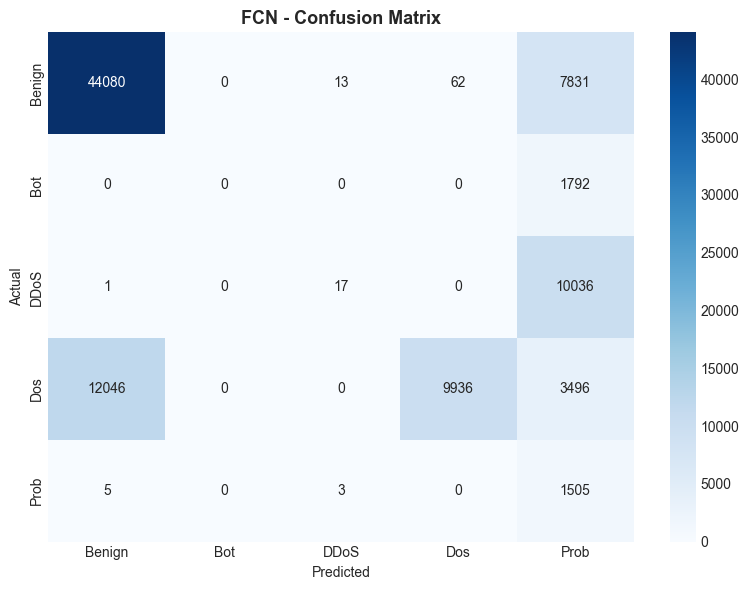

In [33]:
print('=== 6.5 FCN Model (from [P1]: 3 layers - 128, 256, 128) ===')

def build_fcn(input_shape, num_classes, lr=DL_LEARNING_RATE):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(128, kernel_size=8, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        layers.Conv1D(256, kernel_size=5, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        layers.Conv1D(128, kernel_size=3, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        layers.GlobalAveragePooling1D(),
        layers.Dense(num_classes, activation='softmax')
    ])
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

fcn_model = build_fcn((n_features, 1), NUM_CLASSES)
fcn_model, fcn_history = train_and_evaluate_dl(
    'FCN', fcn_model, X_train_cnn, y_train_cat, X_test_cnn, y_test_cat
)

=== 6.6 DL Training Curves ===


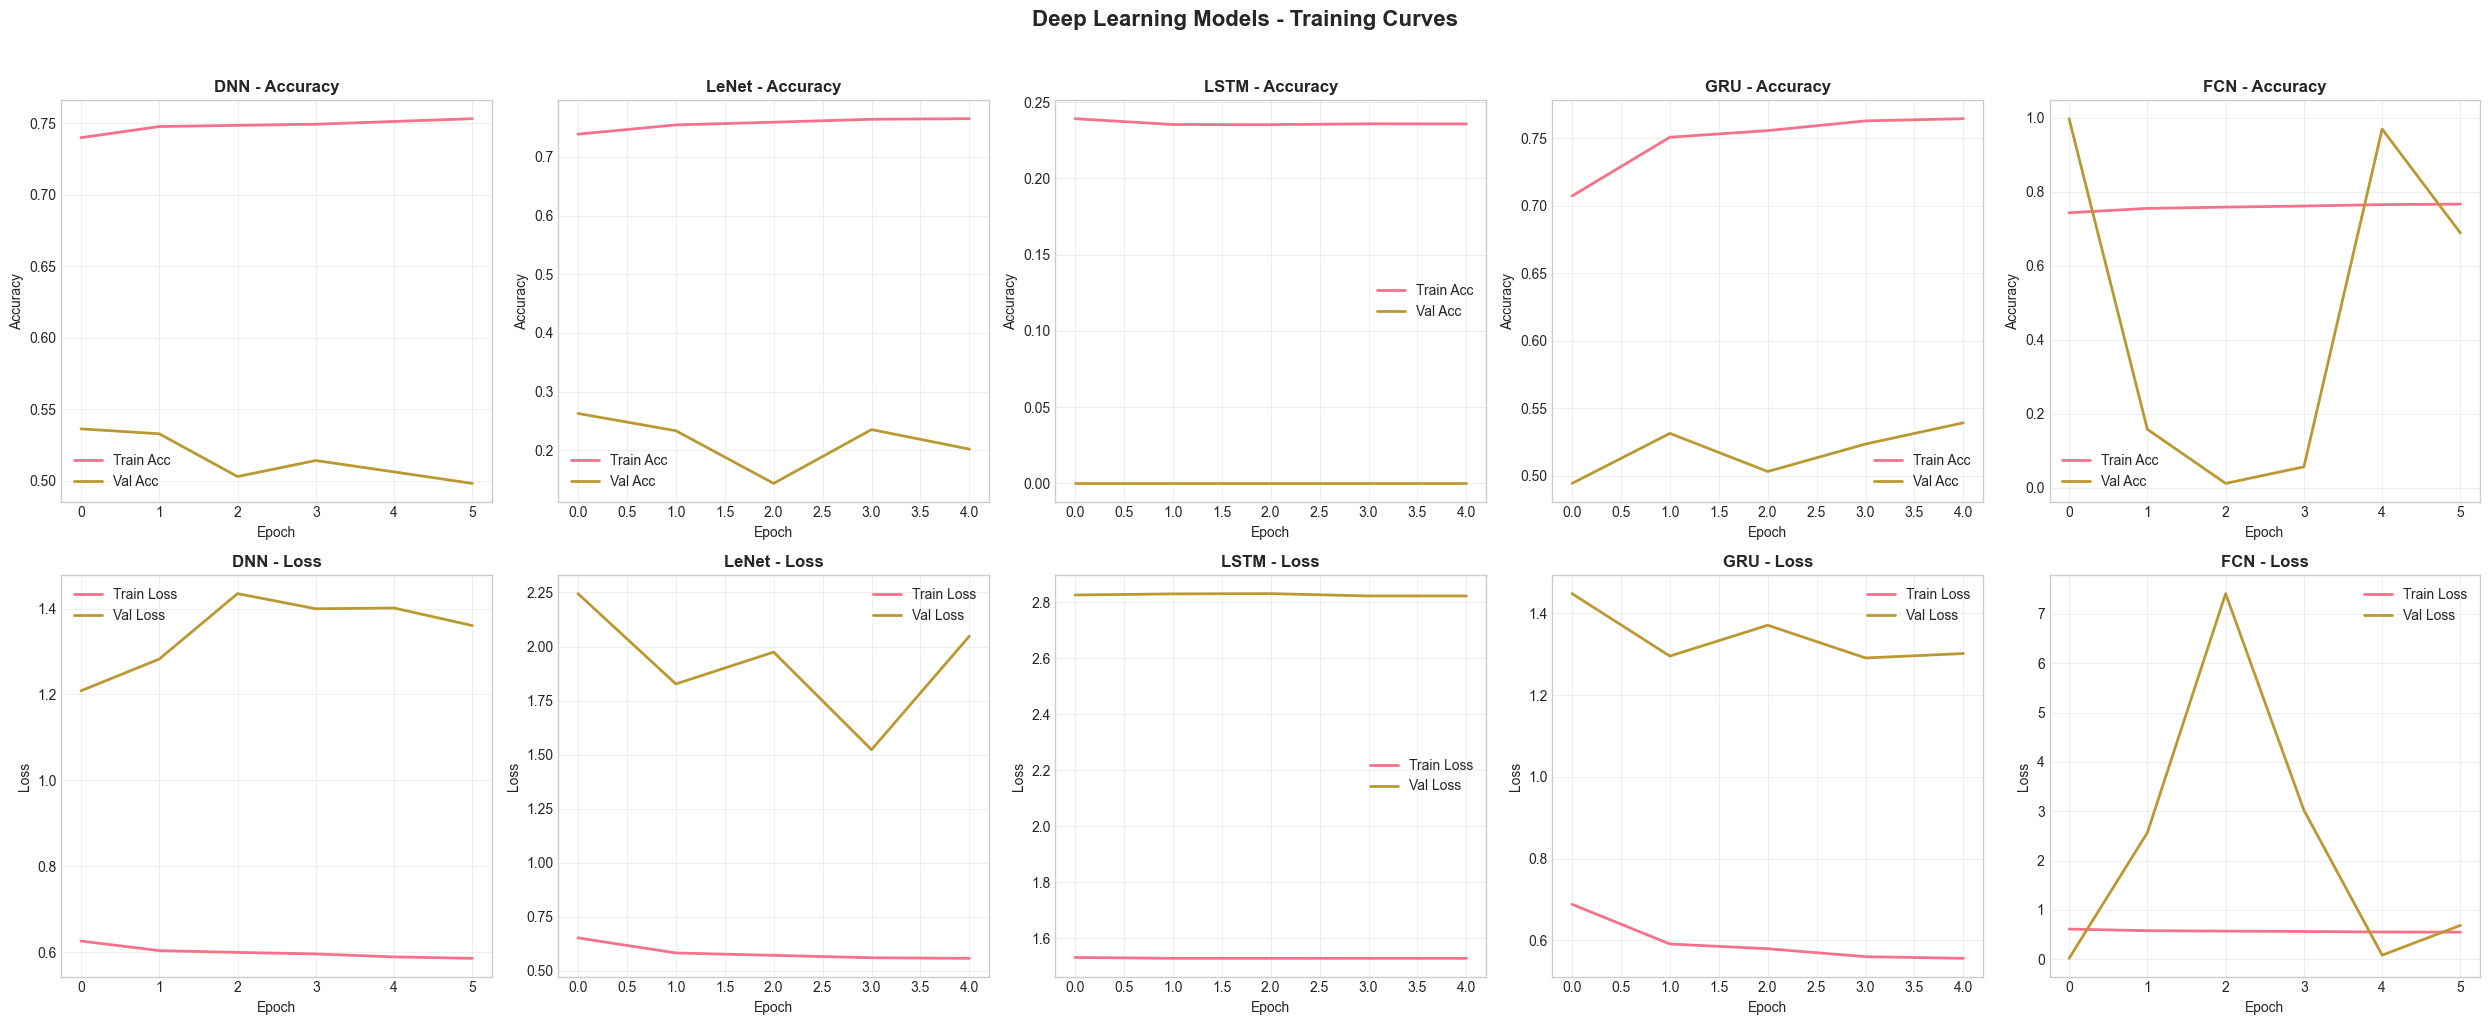

In [34]:
print('=== 6.6 DL Training Curves ===')
if not dl_histories:
    print('No DL training histories to plot (run section 6 first).')
else:
    def _acc_keys(hist):
        if 'accuracy' in hist:
            return 'accuracy', 'val_accuracy'
        if 'sparse_categorical_accuracy' in hist:
            return 'sparse_categorical_accuracy', 'val_sparse_categorical_accuracy'
        return None, None

    n = len(dl_histories)
    fig, axes = plt.subplots(2, n, figsize=(5 * max(n, 1), 10))
    if n == 1:
        axes = axes.reshape(-1, 1)

    for i, (name, hist) in enumerate(dl_histories.items()):
        ak, vak = _acc_keys(hist)
        if ak and vak and ak in hist and vak in hist:
            axes[0, i].plot(hist[ak], label='Train Acc', linewidth=2)
            axes[0, i].plot(hist[vak], label='Val Acc', linewidth=2)
        axes[0, i].set_title(f'{name} - Accuracy', fontweight='bold')
        axes[0, i].set_xlabel('Epoch')
        axes[0, i].set_ylabel('Accuracy')
        axes[0, i].legend()
        axes[0, i].grid(True, alpha=0.3)

        axes[1, i].plot(hist['loss'], label='Train Loss', linewidth=2)
        axes[1, i].plot(hist['val_loss'], label='Val Loss', linewidth=2)
        axes[1, i].set_title(f'{name} - Loss', fontweight='bold')
        axes[1, i].set_xlabel('Epoch')
        axes[1, i].set_ylabel('Loss')
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)

    plt.suptitle('Deep Learning Models - Training Curves', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('dl_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


## 7. Federated Learning (Federated Averaging - FedAvg)

Simulates multiple clients on the balanced training set, trains locally, then aggregates weights (FedAvg).


=== 7. Federated Learning (FedAvg) ===
[FL-DNN] Round 1/3
[FL-DNN] Round 2/3
[FL-DNN] Round 3/3

  FL-DNN Results
  Accuracy:  0.7993 (79.93%)
  Precision: 0.8970
  Recall:    0.7993
  F1 Score:  0.8367


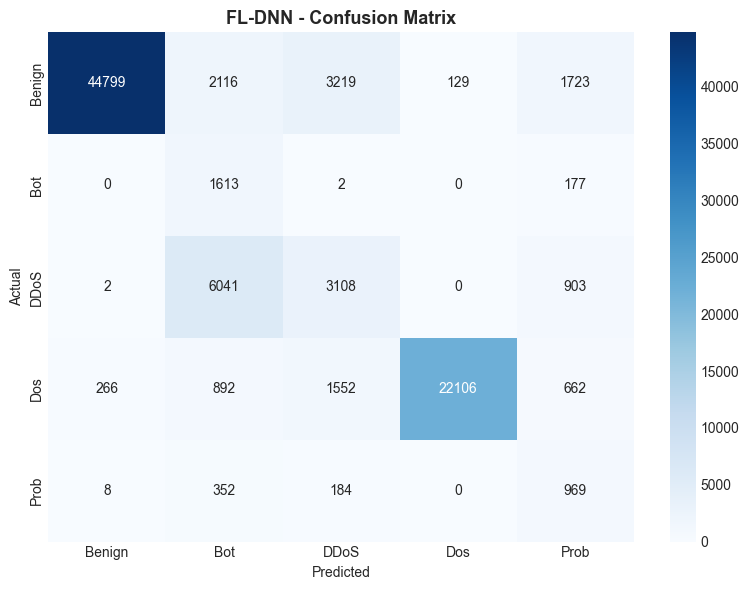

[FL-CNN] Round 1/3
[FL-CNN] Round 2/3
[FL-CNN] Round 3/3

  FL-LeNet Results
  Accuracy:  0.7875 (78.75%)
  Precision: 0.8878
  Recall:    0.7875
  F1 Score:  0.8260


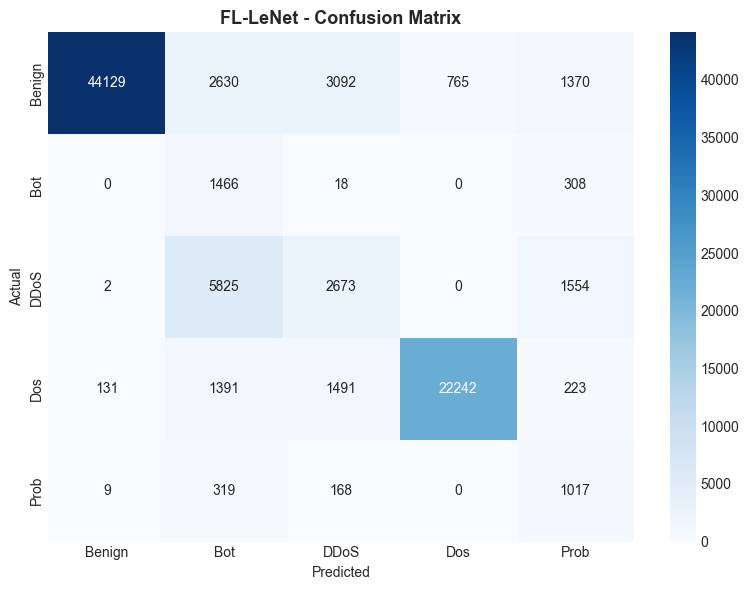

In [35]:
print("=== 7. Federated Learning (FedAvg) ===")

FL_NUM_CLIENTS = 5
FL_ROUNDS = 3
FL_LOCAL_EPOCHS = 2
FL_BATCH_SIZE = 256

# Split the balanced training set into client partitions (random but reproducible).
all_indices = np.arange(X_train_balanced.shape[0])
rng = np.random.RandomState(RANDOM_STATE)
rng.shuffle(all_indices)
client_splits = np.array_split(all_indices, FL_NUM_CLIENTS)

def fedavg_train_dnn(global_model, build_model_fn, X_tr_2d, y_tr_cat, rounds):
    # FedAvg for 2D models (DNN): returns trained global model.
    global_weights = global_model.get_weights()
    for rnd in range(rounds):
        local_weights = []
        print(f"[FL-DNN] Round {rnd+1}/{rounds}")
        for i, idx in enumerate(client_splits):
            local_model = build_model_fn()
            local_model.set_weights(global_weights)
            local_model.fit(
                X_tr_2d[idx],
                y_tr_cat[idx],
                epochs=FL_LOCAL_EPOCHS,
                batch_size=FL_BATCH_SIZE,
                verbose=0,
            )
            local_weights.append(local_model.get_weights())

        # Average weights across clients.
        new_weights = []
        for w_i in range(len(global_weights)):
            stacked = np.stack([lw[w_i] for lw in local_weights], axis=0)
            new_weights.append(np.mean(stacked, axis=0))
        global_weights = new_weights
        global_model.set_weights(global_weights)

    return global_model

def fedavg_train_cnn(global_model, build_model_fn, X_tr_cnn, y_tr_cat, rounds):
    # FedAvg for CNN/sequence models (LeNet/LSTM/GRU/FCN): returns trained global model.
    global_weights = global_model.get_weights()
    for rnd in range(rounds):
        local_weights = []
        print(f"[FL-CNN] Round {rnd+1}/{rounds}")
        for i, idx in enumerate(client_splits):
            local_model = build_model_fn()
            local_model.set_weights(global_weights)
            local_model.fit(
                X_tr_cnn[idx],
                y_tr_cat[idx],
                epochs=FL_LOCAL_EPOCHS,
                batch_size=FL_BATCH_SIZE,
                verbose=0,
            )
            local_weights.append(local_model.get_weights())

        new_weights = []
        for w_i in range(len(global_weights)):
            stacked = np.stack([lw[w_i] for lw in local_weights], axis=0)
            new_weights.append(np.mean(stacked, axis=0))
        global_weights = new_weights
        global_model.set_weights(global_weights)

    return global_model

# --- Federated DNN ---
fl_dnn_model = build_dnn(n_features, NUM_CLASSES)
fl_dnn_model = fedavg_train_dnn(
    fl_dnn_model,
    lambda: build_dnn(n_features, NUM_CLASSES),
    X_train_balanced,
    y_train_cat,
    FL_ROUNDS,
)

fl_dnn_proba = fl_dnn_model.predict(X_test_scaled, verbose=0)
fl_dnn_pred = np.argmax(fl_dnn_proba, axis=1)
evaluate_model("FL-DNN", y_test, fl_dnn_pred, fl_dnn_proba)
plot_confusion_matrix("FL-DNN", y_test, fl_dnn_pred)

# --- Federated LeNet (CNN) ---
fl_lenet_model = build_lenet((n_features, 1), NUM_CLASSES)
fl_lenet_model = fedavg_train_cnn(
    fl_lenet_model,
    lambda: build_lenet((n_features, 1), NUM_CLASSES),
    X_train_cnn,
    y_train_cat,
    FL_ROUNDS,
)

fl_lenet_proba = fl_lenet_model.predict(X_test_cnn, verbose=0)
fl_lenet_pred = np.argmax(fl_lenet_proba, axis=1)
evaluate_model("FL-LeNet", y_test, fl_lenet_pred, fl_lenet_proba)
plot_confusion_matrix("FL-LeNet", y_test, fl_lenet_pred)


## 8. Reinforcement Learning (DQN Agent)

Treats intrusion classification as an RL action-selection problem:
state = feature vector, action = predicted class, reward = 1 if correct else 0.


=== 8. Reinforcement Learning (DQN) ===
[DQN] Episode 1/3 | epsilon=1.000
[DQN] Episode 2/3 | epsilon=0.950
[DQN] Episode 3/3 | epsilon=0.902
[DQN] Evaluating on test set...

  DQN Results
  Accuracy:  0.7815 (78.15%)
  Precision: 0.8880
  Recall:    0.7815
  F1 Score:  0.8231


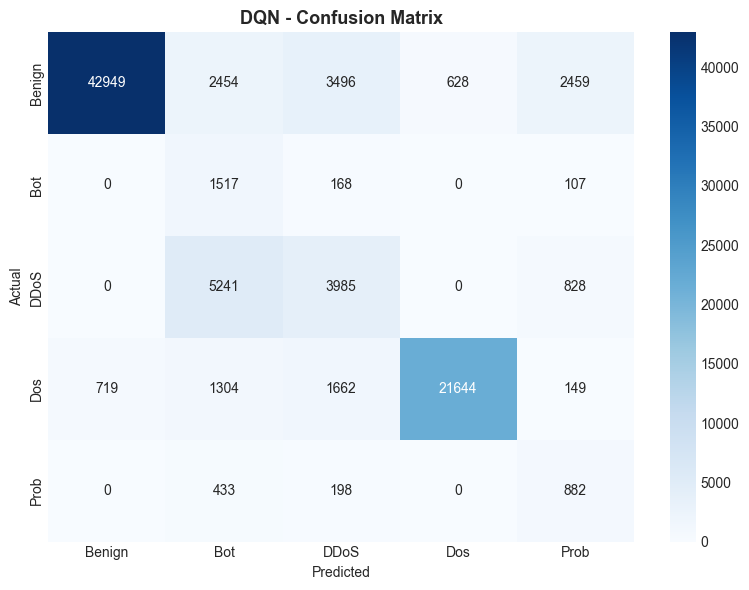

In [36]:
print("=== 8. Reinforcement Learning (DQN) ===")

# DQN hyperparameters (kept small so the notebook can finish on CPU).
RL_EPISODES = 3
RL_STEPS_PER_EPISODE = 80
RL_BATCH_SIZE = 256
RL_EPS_START = 1.0
RL_EPS_MIN = 0.1
RL_EPS_DECAY = 0.95
RL_LR = 1e-3

state_size = n_features
action_size = NUM_CLASSES

dqn_model = keras.Sequential([
    layers.Input(shape=(state_size,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(action_size, activation="linear"),
])

dqn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=RL_LR),
    loss="mse",
)

class SimpleDQNAgent:
    def __init__(self, model):
        self.model = model

agent = SimpleDQNAgent(dqn_model)

X_data = X_train_balanced.astype(np.float32)
y_data = y_train_balanced.astype(np.int32)

epsilon = RL_EPS_START
for ep in range(RL_EPISODES):
    print(f"[DQN] Episode {ep+1}/{RL_EPISODES} | epsilon={epsilon:.3f}")
    for step in range(RL_STEPS_PER_EPISODE):
        batch_idx = np.random.choice(X_data.shape[0], size=RL_BATCH_SIZE, replace=True)
        states = X_data[batch_idx]
        true_labels = y_data[batch_idx]

        # Q(s, a) for all actions.
        q_vals = dqn_model.predict(states, verbose=0)

        # Epsilon-greedy action selection.
        rand_mask = np.random.rand(RL_BATCH_SIZE) < epsilon
        random_actions = np.random.randint(0, action_size, size=RL_BATCH_SIZE)
        greedy_actions = np.argmax(q_vals, axis=1)
        actions = np.where(rand_mask, random_actions, greedy_actions)

        # Reward: 1 if the action matches the true class, else 0.
        rewards = (actions == true_labels).astype(np.float32)

        # Terminal-after-one-step update (gamma term becomes 0).
        target_q = q_vals.copy()
        target_q[np.arange(RL_BATCH_SIZE), actions] = rewards

        dqn_model.fit(states, target_q, epochs=1, batch_size=RL_BATCH_SIZE, verbose=0)

    epsilon = max(RL_EPS_MIN, epsilon * RL_EPS_DECAY)

print("[DQN] Evaluating on test set...")
q_test = dqn_model.predict(X_test_scaled, verbose=0)
dqn_pred = np.argmax(q_test, axis=1)
dqn_proba = tf.nn.softmax(q_test, axis=1).numpy()

evaluate_model("DQN", y_test, dqn_pred, dqn_proba)
plot_confusion_matrix("DQN", y_test, dqn_pred)


---
## 9. Save Models

Writes **traditional ML** to `Saved models\Traditional_ML` and **Keras** models to `Saved models\Deep_Learning`. Shared `scaler`, `label_encoder`, `feature_cols`, and `model_info.json` go in `Saved models`.


In [37]:
print("=== Save all trained models ===")

SAVE_ROOT = r"D:\NSU Course\2026\CSE 499A\Dataset 2025\Saved models"
DIR_ML = os.path.join(SAVE_ROOT, "Traditional_ML")
DIR_DL = os.path.join(SAVE_ROOT, "Deep_Learning")
os.makedirs(DIR_ML, exist_ok=True)
os.makedirs(DIR_DL, exist_ok=True)

def _has(name: str) -> bool:
    return name in globals() and globals()[name] is not None

# --- Traditional ML (joblib) ---
if _has("rf_model"):
    joblib.dump(rf_model, os.path.join(DIR_ML, "random_forest.joblib"))
else:
    print("WARNING: rf_model not available; skipping Random Forest save.")

if _has("HAS_XGB") and HAS_XGB and _has("xgb_model"):
    joblib.dump(xgb_model, os.path.join(DIR_ML, "xgboost.joblib"))

if _has("HAS_LGB") and HAS_LGB and _has("lgb_model"):
    joblib.dump(lgb_model, os.path.join(DIR_ML, "lightgbm.joblib"))

# --- Deep Learning (Keras) ---
for model_name, file_name in [
    ("dnn_model", "dnn_model.keras"),
    ("lenet_model", "lenet_model.keras"),
    ("lstm_model", "lstm_model.keras"),
    ("gru_model", "gru_model.keras"),
    ("fcn_model", "fcn_model.keras"),
    ("fl_dnn_model", "fl_dnn_model.keras"),
    ("fl_lenet_model", "fl_lenet_model.keras"),
]:
    if _has(model_name):
        globals()[model_name].save(os.path.join(DIR_DL, file_name))
    else:
        print(f"INFO: {model_name} not available; skipping save.")

if _has("dqn_model"):
    dqn_model.save(os.path.join(DIR_DL, "dqn_model.keras"))
elif _has("agent") and hasattr(agent, "model") and agent.model is not None:
    agent.model.save(os.path.join(DIR_DL, "dqn_model.keras"))

# Shared preprocessing artifacts (in SAVE_ROOT).
if _has("scaler"):
    joblib.dump(scaler, os.path.join(SAVE_ROOT, "scaler.joblib"))
if _has("label_encoder"):
    joblib.dump(label_encoder, os.path.join(SAVE_ROOT, "label_encoder.joblib"))
if _has("feature_cols"):
    joblib.dump(feature_cols, os.path.join(SAVE_ROOT, "feature_cols.joblib"))

model_info = {
    "num_features": int(n_features),
    "num_classes": int(NUM_CLASSES),
    "class_names": CLASS_NAMES,
    "feature_columns": feature_cols,
    "traditional_ml_dir": DIR_ML,
    "deep_learning_dir": DIR_DL,
    "has_xgboost": bool(_has("HAS_XGB") and HAS_XGB),
    "has_lightgbm": bool(_has("HAS_LGB") and HAS_LGB),
    "has_federated_models": bool(_has("fl_dnn_model") or _has("fl_lenet_model")),
    "has_dqn": bool(_has("dqn_model") or (_has("agent") and hasattr(agent, "model"))),
}

with open(os.path.join(SAVE_ROOT, "model_info.json"), "w", encoding="utf-8") as f:
    json.dump(model_info, f, indent=2)

print("Saved successfully.")
print("  Traditional ML:", DIR_ML)
print("  Deep Learning: ", DIR_DL)
print("  Artifacts:     ", SAVE_ROOT)


=== Save all trained models ===
Saved successfully.
  Traditional ML: D:\NSU Course\2026\CSE 499A\Dataset 2025\Saved models\Traditional_ML
  Deep Learning:  D:\NSU Course\2026\CSE 499A\Dataset 2025\Saved models\Deep_Learning
  Artifacts:      D:\NSU Course\2026\CSE 499A\Dataset 2025\Saved models


## 10. Flask Web UI (Localhost)

Starts a small local web server for testing predictions.
Use `/` to open the UI and `/predict` to get predictions from uploaded CSV or comma-separated feature values.


In [1]:
print("=== 10. Flask Web UI ===")

from flask import Flask, request, jsonify, render_template_string
import numpy as np
import pandas as pd
import threading
import tensorflow as tf
import os
import joblib

app = Flask(__name__)

# Directory for models and artifacts
ARTIFACTS_DIR = r"D:\NSU Course\2026\CSE 499A\Dataset 2025\Saved models\Traditional_ML"

# ==========================================
# AUTO-SAVE ARTIFACTS
# If the variables exist in memory, save them permanently so they survive notebook restarts!
# ==========================================
if 'scaler' in globals() and 'label_encoder' in globals() and 'feature_cols' in globals():
    os.makedirs(ARTIFACTS_DIR, exist_ok=True)
    joblib.dump(globals()['scaler'], os.path.join(ARTIFACTS_DIR, 'scaler.pkl'))
    joblib.dump(globals()['label_encoder'], os.path.join(ARTIFACTS_DIR, 'label_encoder.pkl'))
    joblib.dump(globals()['feature_cols'], os.path.join(ARTIFACTS_DIR, 'feature_cols.pkl'))
    print(f"✅ Preprocessing artifacts automatically saved to: {ARTIFACTS_DIR}")
else:
    print("⚠️ Warning: Scaler, Label Encoder, or Feature Cols not found in active memory.")
    print("If the UI throws an error, please run your Data Preparation cells first!")


HTML_INDEX = """
<!doctype html>
<html lang="en">
  <head>
    <meta charset="utf-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0" />
    <title>IDS ML Tester</title>
    <style>
      :root {
        --primary: #4f46e5;
        --primary-hover: #4338ca;
        --bg-start: #e0e7ff;
        --bg-end: #fae8ff;
        --surface: #ffffff;
        --border: #c7d2fe;
        --text: #1e293b;
        --text-light: #64748b;
        --radius: 12px;
        --terminal-bg: #0f172a;
        --terminal-text: #38bdf8;
      }
      
      body { 
        font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif; 
        background: linear-gradient(135deg, var(--bg-start) 0%, var(--bg-end) 100%);
        color: var(--text);
        margin: 0;
        padding: 40px 20px;
        line-height: 1.5;
        min-height: 100vh;
        box-sizing: border-box;
      }

      /* Widened container for the two-column layout */
      .container {
        max-width: 1100px;
        margin: 0 auto;
        background: var(--surface);
        padding: 32px;
        border-radius: var(--radius);
        box-shadow: 0 10px 25px -5px rgba(79, 70, 229, 0.15), 0 8px 10px -6px rgba(79, 70, 229, 0.1);
        border-top: 5px solid var(--primary);
      }

      h2 { 
        margin-top: 0; 
        margin-bottom: 24px;
        font-size: 1.75rem; 
        font-weight: 700;
        color: var(--primary);
        text-align: center;
      }

      h3 {
        margin-top: 0;
        font-size: 1.1rem;
        font-weight: 600;
        color: var(--text);
      }

      /* CSS Grid to create side-by-side layout */
      .layout-grid {
        display: grid;
        grid-template-columns: 1fr 1fr;
        gap: 40px;
      }

      /* Stack vertically on smaller screens */
      @media (max-width: 768px) {
        .layout-grid {
          grid-template-columns: 1fr;
        }
      }

      .form-group { margin-bottom: 20px; }

      label { 
        display: block; 
        font-weight: 600; 
        margin-bottom: 8px; 
        font-size: 0.95rem;
      }

      select, input[type="file"], textarea {
        width: 100%;
        padding: 12px;
        border: 2px solid var(--border);
        border-radius: 8px;
        background-color: #f8fafc;
        font-family: inherit;
        font-size: 0.95rem;
        box-sizing: border-box;
      }

      textarea { resize: vertical; min-height: 120px; }

      .divider {
        display: flex;
        align-items: center;
        text-align: center;
        margin: 24px 0;
        color: var(--text-light);
        font-size: 0.85rem;
        font-weight: 700;
        text-transform: uppercase;
      }
      .divider::before, .divider::after {
        content: '';
        flex: 1;
        border-bottom: 2px dashed var(--border);
      }
      .divider:not(:empty)::before { margin-right: 16px; }
      .divider:not(:empty)::after { margin-left: 16px; }

      .hint {
        font-size: 0.85rem;
        color: var(--text-light);
        margin-top: 8px;
        background: #f1f5f9;
        padding: 12px;
        border-radius: 8px;
        border-left: 4px solid var(--primary);
      }

      code { 
        background: #e2e8f0; 
        padding: 2px 6px; 
        border-radius: 4px; 
        color: #be185d; 
        font-weight: 600;
      }

      button {
        background-color: var(--primary);
        color: white;
        border: none;
        padding: 14px 24px;
        font-size: 1.05rem;
        font-weight: 600;
        border-radius: 8px;
        cursor: pointer;
        width: 100%;
        margin-top: 8px;
      }

      button:hover:not(:disabled) { 
        background-color: var(--primary-hover);
      }
      
      button:disabled {
        background-color: var(--text-light);
        cursor: not-allowed;
      }

      .result-container {
        display: flex;
        flex-direction: column;
        height: 100%;
        background: #f8fafc;
        padding: 20px;
        border-radius: 8px;
        border: 1px solid var(--border);
      }

      pre { 
        background: var(--terminal-bg); 
        padding: 16px; 
        border-radius: 8px; 
        overflow-x: auto; 
        font-size: 0.9rem;
        color: var(--terminal-text);
        margin: 0;
        flex-grow: 1;
        min-height: 300px;
      }
    </style>
  </head>
  <body>
    <div class="container">
      <h2>Intrusion Detection System</h2>
      
      <div class="layout-grid">
        <div class="input-panel">
          <div class="form-group">
            <label for="model">Select Model</label>
            <select id="model">
              {% for m in model_options %}
                <option value="{{m}}">{{m}}</option>
              {% endfor %}
            </select>
          </div>

          <div class="form-group">
            <label for="csvfile">Upload Dataset (CSV)</label>
            <input type="file" id="csvfile" accept=".csv"/>
          </div>

          <div class="divider">or</div>

          <div class="form-group">
            <label for="features">Enter Raw Features</label>
            <textarea id="features" placeholder="e.g. 0.0, 1.2, 3.4..."></textarea>
            <div class="hint">
              <strong>Requires exactly <code>{{feature_count}}</code> comma-separated values.</strong><br/>
              <span style="display:inline-block; margin-top:4px;">First expected features: <br/><code>{{feature_preview}}</code></span>
            </div>
          </div>

          <button id="btn-predict" onclick="predict()">Run Prediction</button>
        </div>

        <div class="result-panel">
          <div class="result-container">
            <h3>Results</h3>
            <pre id="out">Awaiting input...</pre>
          </div>
        </div>
      </div>
    </div>

    <script>
      async function predict() {
        const btn = document.getElementById('btn-predict');
        const out = document.getElementById('out');
        
        btn.disabled = true;
        btn.textContent = 'Processing...';
        out.textContent = 'Sending request...';

        const model = document.getElementById('model').value;
        const fileInput = document.getElementById('csvfile');
        const features = document.getElementById('features').value.trim();

        const form = new FormData();
        form.append('model', model);

        if (fileInput.files.length > 0) {
          form.append('file', fileInput.files[0]);
        } else {
          if (!features) {
            out.textContent = 'Error: Provide either a CSV file or comma-separated feature values.';
            btn.disabled = false;
            btn.textContent = 'Run Prediction';
            return;
          }
          form.append('features', features);
        }

        try {
          const resp = await fetch('/predict', { method: 'POST', body: form });
          const data = await resp.json();
          out.textContent = JSON.stringify(data, null, 2);
        } catch (e) {
          out.textContent = 'Error: ' + e.message;
        } finally {
          btn.disabled = false;
          btn.textContent = 'Run Prediction';
        }
      }
    </script>
  </body>
</html>
"""

def get_model_file_paths():
    # Hardcoded paths, with LSTM removed and LightGBM updated
    return {
        "RandomForest": r"D:\NSU Course\2026\CSE 499A\Dataset 2025\Saved models\Traditional_ML\random_forest.joblib",
        "XGBoost": r"D:\NSU Course\2026\CSE 499A\Dataset 2025\Saved models\Traditional_ML\xgboost.joblib",
        "LightGBM": r"D:\NSU Course\2026\CSE 499A\New Try\Dataset 2025\Saved models\Traditional_ML\lightgbm.joblib",
        "GRU": r"D:\NSU Course\2026\CSE 499A\Dataset 2025\Saved models\Deep_Learning\gru_model.keras"
    }

def load_artifacts():
    # Try global scope first, then fallback to disk using the ARTIFACTS_DIR
    scaler = globals().get('scaler')
    le = globals().get('label_encoder')
    fc = globals().get('feature_cols')

    try:
        if scaler is None and os.path.exists(os.path.join(ARTIFACTS_DIR, 'scaler.pkl')):
            scaler = joblib.load(os.path.join(ARTIFACTS_DIR, 'scaler.pkl'))
        if le is None and os.path.exists(os.path.join(ARTIFACTS_DIR, 'label_encoder.pkl')):
            le = joblib.load(os.path.join(ARTIFACTS_DIR, 'label_encoder.pkl'))
        if fc is None and os.path.exists(os.path.join(ARTIFACTS_DIR, 'feature_cols.pkl')):
            fc = joblib.load(os.path.join(ARTIFACTS_DIR, 'feature_cols.pkl'))
    except Exception as e:
        print(f"Error loading artifacts from disk: {e}")
        
    return scaler, le, fc

def _selected_model(model_key: str):
    paths = get_model_file_paths()
    path = paths.get(model_key)
    
    if not path or not os.path.exists(path):
        raise ValueError(f"Model file for {model_key} not found at {path}. Did you train and save it?")

    if model_key in ["RandomForest", "XGBoost", "LightGBM"]:
        model = joblib.load(path)
        kind = "traditional_2d"
    else:
        # GRUs, etc.
        model = tf.keras.models.load_model(path)
        kind = "keras_cnn"
        
    return model, kind

def _predict_internal(model_key: str, X_raw: np.ndarray):
    model, kind = _selected_model(model_key)
    scaler, label_encoder, feature_cols = load_artifacts()

    if scaler is None or label_encoder is None:
        raise ValueError(f"Scaler or LabelEncoder not found. Please ensure scaler.pkl and label_encoder.pkl are inside: {ARTIFACTS_DIR}")

    X_scaled = scaler.transform(X_raw)
    n = len(feature_cols)

    if kind == "traditional_2d":
        y_pred = model.predict(X_scaled)
        y_proba = model.predict_proba(X_scaled) if hasattr(model, "predict_proba") else None
    elif kind == "keras_cnn":
        X_in = X_scaled.reshape(-1, n, 1)
        y_proba = model.predict(X_in, verbose=0)
        y_pred = np.argmax(y_proba, axis=1)
    else:
        raise ValueError(f"Unsupported model kind: {kind}")

    pred_labels = label_encoder.inverse_transform(y_pred)
    out = {
        "num_rows": int(X_raw.shape[0]),
        "predictions": [
            {
                "pred_class_id": int(y_pred[i]),
                "pred_label": str(pred_labels[i]),
                "proba": (None if y_proba is None else [float(x) for x in y_proba[i]]),
            }
            for i in range(X_raw.shape[0])
        ],
    }
    return out

@app.route("/", methods=["GET"])
def index():
    options = []
    paths = get_model_file_paths()
    
    # Show model only if the file actively exists on disk
    for name, path in paths.items():
        if os.path.exists(path):
            options.append(name)

    if not options:
        options = ["No models found at the exact paths provided."]

    _, _, f_cols = load_artifacts()
    f_count = len(f_cols) if f_cols else "Unknown"
    f_preview = str(f_cols[:10]) if f_cols else f"Could not load feature_cols.pkl from {ARTIFACTS_DIR}"

    return render_template_string(
        HTML_INDEX,
        model_options=options,
        feature_count=f_count,
        feature_preview=f_preview,
    )

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok"})

@app.route("/predict", methods=["POST"])
def predict():
    _, _, f_cols = load_artifacts()
    if not f_cols:
        return jsonify({"error": f"Data tools missing. Please run the notebook cells that define your dataset, scaler, and label encoder first!"}), 400

    model_key = request.form.get("model", "RandomForest")

    file = request.files.get("file")
    if file is not None and file.filename:
        df = pd.read_csv(file)
        missing = [c for c in f_cols if c not in df.columns]
        if missing:
            return jsonify({"error": "CSV missing required feature columns.", "missing": missing[:20]}), 400

        X_raw = df[f_cols].values.astype(np.float32)
        if X_raw.shape[0] > 100:
            X_raw = X_raw[:100]
        try:
            return jsonify(_predict_internal(model_key, X_raw))
        except Exception as e:
            return jsonify({"error": str(e)}), 500

    features = request.form.get("features", "").strip()
    if not features:
        return jsonify({"error": "Provide either a CSV file or comma-separated features."}), 400

    parts = [p.strip() for p in features.split(",") if p.strip() != ""]
    if len(parts) != len(f_cols):
        return jsonify({
            "error": "Feature count mismatch.",
            "expected": len(f_cols),
            "received": len(parts),
        }), 400

    try:
        X_raw = np.array([list(map(float, parts))], dtype=np.float32)
        return jsonify(_predict_internal(model_key, X_raw))
    except Exception as e:
        return jsonify({"error": str(e)}), 500

START_FLASK_SERVER = True
if START_FLASK_SERVER:
    import socket
    def _find_free_port(host="127.0.0.1", start_port=5000):
        port = start_port
        while True:
            with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
                try:
                    s.bind((host, port))
                    s.listen(1)
                    return port
                except OSError:
                    port += 1
    port = _find_free_port()
    def _run():
        app.run(host="127.0.0.1", port=port, debug=False, use_reloader=False)

    t = threading.Thread(target=_run, daemon=True)
    t.start()
    print(f"Flask UI running at: http://127.0.0.1:{port}")
    print(f"Prediction endpoint: POST http://127.0.0.1:{port}/predict")

=== 10. Flask Web UI ===
⚠️ Warning: Scaler, Label Encoder, or Feature Cols not found in active memory.
If the UI throws an error, please run your Data Preparation cells first!
Flask UI running at: http://127.0.0.1:5000
Prediction endpoint: POST http://127.0.0.1:5000/predict
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [07/Apr/2026 13:20:40] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [07/Apr/2026 13:20:41] "GET /favicon.ico HTTP/1.1" 404 -


---
## 11. Summary & Conclusion


In [39]:
print('=' * 70)
print('  PROJECT SUMMARY')
print('=' * 70)
print(f'\nDataset: ASEADOS_SDN_IoT ({df.shape[0]:,} samples, {n_features} features)')
print(f'Classes: {CLASS_NAMES}')
print(f'\n{"Model":<20} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1 Score":>10}')
print('-' * 62)
for name in sorted(results.keys(), key=lambda x: results[x]['Accuracy'], reverse=True):
    r = results[name]
    print(f'{name:<20} {r["Accuracy"]*100:>9.2f}% {r["Precision"]*100:>9.2f}% '
          f'{r["Recall"]*100:>9.2f}% {r["F1 Score"]*100:>9.2f}%')

best_model = max(results.keys(), key=lambda x: results[x]['Accuracy'])
print(f'\nBest overall model: {best_model} ({results[best_model]["Accuracy"]*100:.2f}% accuracy)')

print('\nSaved model locations:')
print(r'  D:\NSU Course\2026\CSE 499A\Dataset 2025\Saved models\Traditional_ML')
print(r'  D:\NSU Course\2026\CSE 499A\Dataset 2025\Saved models\Deep_Learning')
print('=' * 70)


  PROJECT SUMMARY

Dataset: ASEADOS_SDN_IoT (454,112 samples, 42 features)
Classes: ['Benign', 'Bot', 'DDoS', 'Dos', 'Prob']

Model                  Accuracy  Precision     Recall   F1 Score
--------------------------------------------------------------
XGBoost                  84.03%     91.19%     84.03%     86.78%
Random Forest            83.98%     90.90%     83.98%     86.64%
LightGBM                 83.57%     91.26%     83.57%     86.52%
GRU                      81.19%     89.97%     81.19%     84.62%
DNN                      80.36%     89.94%     80.36%     84.15%
FL-DNN                   79.93%     89.70%     79.93%     83.67%
FL-LeNet                 78.75%     88.78%     78.75%     82.60%
DQN                      78.15%     88.80%     78.15%     82.31%
LeNet                    64.10%     63.92%     64.10%     55.11%
FCN                      61.15%     78.63%     61.15%     62.62%
LSTM                      1.97%      0.04%      1.97%      0.08%

Best overall model: XGBoost (8